# Initial Processing & Construction Identification
---
This notebook aims to identify new constructions, demolitions, the replacement pairs between the demolitions and new constructions based on their geolocations, demolition year, and construction years (i.e., hard densification), and buildings with the change of purpose (i.e., one type of soft densification) from the Swiss Federal Register of Buildings and Dwellings from 2000 to 2025.

## Environment & Loading
---

### Environment

In [289]:
import os
from pathlib import Path
import pandas as pd
import gc
import geopandas as gpd
import csv

In [2]:
pd.set_option('display.max_columns', None)

### Loading

1. `GEB`: The comprehensive building registration as the base df to idenftiy construction and demolition activities.
2. `EIN`: The entrance dataset linked to `GEB` through `EGID` (Federal Building Identifier). This df is used to spatially join demolished and replacement buildings, where both are identified from `GEB`
3. `ARB`: The work dataset linked to `GEB` through `EGID`, which is mainly used to extract the records for soft densification.

In [3]:
ROOT = Path("/Volumes/shared/data/una-gwr/GWR Data")
ROOT.exists()

True

#### 1. `GEB`

In [4]:
GEB_FILE = ROOT / "GWR_MADD_GEB-10_Data_MADD-20251130-A1_20251204.dsv"
GEB_FILE.exists()

True

In [5]:
# Print the delimiter
with open(GEB_FILE, "r", encoding="utf-8", errors="replace") as f:
    GEB_SEP = csv.Sniffer().sniff(f.read(8192)).delimiter

print("GEB_SEP:", repr(GEB_SEP))

GEB_SEP: '\t'


In [6]:
GEB = pd.read_csv(
    GEB_FILE,
    sep=GEB_SEP,
    encoding="utf-8",
    encoding_errors="replace",
    low_memory=False,
    dtype=str
)

In [7]:
GEB["GKODE"] = pd.to_numeric(GEB["GKODE"], errors="coerce")
GEB["GKODN"] = pd.to_numeric(GEB["GKODN"], errors="coerce")

GEB = gpd.GeoDataFrame(
    GEB.copy(),
    geometry=gpd.points_from_xy(GEB["GKODE"], GEB["GKODN"]),
    crs="EPSG:2056"
)

In [8]:
GEB

,EGID,GEBNR,GBEZ,GKODE,GKODN,GKSCE,GLOC1,GLOC2,GLOC3,GLOC4,GQUART,GSTAT,GKAT,GKLAS,GBAUJ,GBAUM,GBAUJM,GBAUP,GRENJ,GABBJ,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GSCHUTZR,GEBF,GWAERZH1,GENH1,GWAERSCEH1,GWAERDATH1,GWAERZH2,GENH2,GWAERSCEH2,GWAERDATH2,GWAERZW1,GENW1,GWAERSCEW1,GWAERDATW1,GWAERZW2,GENW2,GWAERSCEW2,GWAERDATW2,Create_Date,Update_Date,GGDENR,GDENAME,GDEKT,geometry
0,1600000,164,NaN,2679677.869,1237453.256,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1110,1845,1,1845-01,8011,NaN,NaN,165,NaN,NaN,NaN,3,NaN,0,NaN,7410,7501,869,2024-03-28,7400,7500,852,2024-03-28,7610,7501,869,2024-03-28,7600,7500,852,2024-03-28,2001-11-29,2024-03-28,1,Aeugst am Albis,ZH,POINT (2679677.869 1237453.256)
1,1600001,154,NaN,2679692.997,1237491.284,901,NaN,NaN,NaN,NaN,NaN,1004,1030,1110,1900,NaN,1900,8011,NaN,NaN,313,NaN,NaN,NaN,2,NaN,NaN,NaN,7436,7530,869,2014-01-14,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2021-03-18,1,Aeugst am Albis,ZH,POINT (2679692.997 1237491.284)
2,1600002,158,NaN,2679721.955,1237479.329,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1122,1871,6,1871-06,8011,NaN,NaN,302,3072,869,969,3,NaN,NaN,NaN,7410,7598,869,2021-11-05,NaN,NaN,NaN,NaN,7610,7598,869,2021-11-05,NaN,NaN,NaN,NaN,2001-11-29,2025-04-01,1,Aeugst am Albis,ZH,POINT (2679721.955 1237479.329)
3,1600003,57,NaN,2679660.647,1237522.495,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1121,1987,NaN,1987,8017,NaN,NaN,206,NaN,NaN,NaN,3,3,NaN,NaN,7431,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7650,7560,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2025-07-28,1,Aeugst am Albis,ZH,POINT (2679660.647 1237522.495)
4,1600005,35,NaN,2679752.242,1237530.436,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1110,1985,NaN,1985,8016,NaN,NaN,113,NaN,NaN,NaN,2,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7650,7560,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2021-03-18,1,Aeugst am Albis,ZH,POINT (2679752.242 1237530.436)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335773,502145670,NaN,NaN,2578555.277,1258527.414,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1274,NaN,NaN,NaN,8017,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578555.277 1258527.414)
3335774,502145671,NaN,NaN,2578518.660,1259249.767,901,NaN,NaN,NaN,NaN,NaN,1004,1060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578518.66 1259249.767)
3335775,502145672,NaN,NaN,2578550.123,1259257.189,901,NaN,NaN,NaN,NaN,NaN,1004,1060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578550.123 1259257.189)
3335776,502145673,NaN,NaN,2579024.275,1259393.521,901,NaN,NaN,NaN,NaN,NaN,1004,1060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2579024.275 1259393.521)


<Axes: >

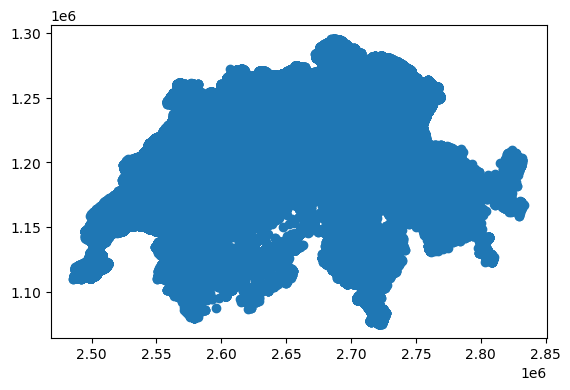

In [9]:
GEB.plot()

#### 2. `EIN`

In [10]:
EIN_FILE = ROOT / "GWR_MADD_EIN-10_Data_MADD-20251130-A1_20251204.dsv"
EIN_FILE.exists()

True

In [11]:
# Print the delimiter
with open(EIN_FILE, "r", encoding="utf-8", errors="replace") as f:
    EIN_SEP = csv.Sniffer().sniff(f.read(8192)).delimiter

print("EIN_SEP:", repr(EIN_SEP))

EIN_SEP: '\t'


In [12]:
EIN = pd.read_csv(
    EIN_FILE,
    sep=EIN_SEP,
    encoding="utf-8",
    encoding_errors="replace",
    low_memory=False,
    dtype=str
)

In [13]:
EIN["DKODE"] = pd.to_numeric(EIN["DKODE"], errors="coerce")
EIN["DKODN"] = pd.to_numeric(EIN["DKODN"], errors="coerce")

EIN = gpd.GeoDataFrame(
    EIN.copy(),
    geometry=gpd.points_from_xy(EIN["DKODE"], EIN["DKODN"]),
    crs="EPSG:2056"
)

In [14]:
EIN.shape

(3423584, 19)

In [15]:
EIN

,EGID,EDID,EGAID,DEINR,DKODE,DKODN,DOFFADR,Create_Date,Update_Date,ESID,STROFFIZIEL,DPLZ4,DPLZZ,DPLZNAME,STRSP,STRNAME,STRNAMK,STRINDX,geometry
0,1600000,0,100962749,1,2679684.326,1237449.553,1,2016-12-14,2024-07-29,10075241,1,8914,2,Aeugstertal,9901,In der Breite,In der Breite,Bre,POINT (2679684.326 1237449.553)
1,1600001,0,100962750,1,2679702.150,1237493.958,1,2016-12-14,2024-07-29,10106390,1,8914,2,Aeugstertal,9901,Pöstliweg,Pöstliweg,Pös,POINT (2679702.15 1237493.958)
2,1600002,1,103174313,4a,2679719.511,1237488.837,1,2021-11-05,2025-03-17,10075241,1,8914,2,Aeugstertal,9901,In der Breite,In der Breite,Bre,POINT (2679719.511 1237488.837)
3,1600002,2,103176425,4b,2679730.395,1237478.622,1,2021-11-11,2025-03-17,10075241,1,8914,2,Aeugstertal,9901,In der Breite,In der Breite,Bre,POINT (2679730.395 1237478.622)
4,1600003,0,100962752,8,2679655.455,1237516.450,1,2016-12-14,2024-07-29,10106390,1,8914,2,Aeugstertal,9901,Pöstliweg,Pöstliweg,Pös,POINT (2679655.455 1237516.45)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3423579,502145670,0,103062581,65.1,2578555.258,1258527.616,1,2021-07-06,2024-07-29,10058407,1,2944,0,Bonfol,9903,Champs aux Oies,Champs aux Oies,Oie,POINT (2578555.258 1258527.616)
3423580,502145671,0,103062778,216j.2,2578518.658,1259249.764,1,2021-07-06,2024-07-29,10050277,1,2944,0,Bonfol,9903,Rue de la Scierie,Rue de la Scierie,Sci,POINT (2578518.658 1259249.764)
3423581,502145672,0,103062792,216j.1,2578550.158,1259257.146,1,2021-07-06,2024-07-29,10050277,1,2944,0,Bonfol,9903,Rue de la Scierie,Rue de la Scierie,Sci,POINT (2578550.158 1259257.146)
3423582,502145673,0,103062509,1.2,2579024.276,1259393.520,1,2021-07-06,2025-11-13,10223572,1,2944,0,Bonfol,9903,Bois Banal,Bois Banal,Boi,POINT (2579024.276 1259393.52)


<Axes: >

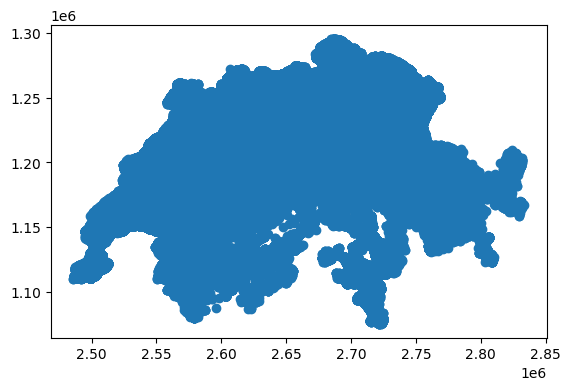

In [16]:
EIN.plot()

In [17]:
GEB.to_file("GEB_EIN.gpkg", layer="GEB", driver="GPKG")
EIN.to_file("GEB_EIN.gpkg", layer="EIN", driver="GPKG")

#### 3. `ARB`

In [18]:
ARB_FILE = ROOT / "GWR_MADD_ARB-10_Data_MADD-20251130-A1_20251204.dsv"
ARB_FILE.exists()

True

In [19]:
ARB = pd.read_csv(
    ARB_FILE,
    sep=GEB_SEP,
    encoding="utf-8",
    encoding_errors="replace",
    low_memory=False,
    dtype=str
)

In [20]:
ARB

,EPROID,ARBID,EGID,PARTAB,PENSAN,PHEIZSAN,PINNUMB,PUMNUTZ,PERWMHZ,PERWOHZ,PTHERSOL,PPHOTSOL,PANDUMB,Create_Date,Update_Date
0,14982,1,20705,6002,0,0,0,0,0,0,0,0,1,2015-09-16,2021-11-20
1,52394,10,210199540,6002,0,0,0,0,0,0,0,0,1,2021-09-27,2023-11-22
2,72217,4,210190053,6001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-29
3,77665,8,210188249,6001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-14,2021-10-14
4,84945,1,111851,6002,0,0,0,0,0,0,0,0,1,NaN,2024-07-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211830,400032992,1,1704467,6002,0,0,0,0,0,0,0,0,1,2021-11-17,2022-05-12
211831,400032996,1,1705616,6002,0,0,0,0,0,0,0,0,1,2021-11-17,2022-05-12
211832,400033034,1,1704396,6002,0,0,0,0,0,0,0,0,1,2021-11-17,2022-05-12
211833,400033041,1,190040491,6002,0,0,0,0,0,0,0,0,1,2021-11-17,2022-05-12


In [21]:
# ARB.to_csv("ARB.csv", index=False)

## Processing
---

The order of the processing of GWR data is:

**1. Identification of New Constructions**

**2. Identification of Demolished Buildings**

**3. Hard Densification**: Identification of Replacement Buildings (Linking the above two together based on Lutz (2023))

**4. Soft Densification**: Identification of Living Space Renovations (i.e., joinning/dividing dwellings; change of purpose; extension)

### 1. Identification of New Constructions

In [22]:
type(GEB.columns)

pandas.core.indexes.base.Index

#### 1.1 Building Category: `GKAT` != 1010 (Temporary accommodation) OR 1080 (Special constructions)

- The left buildings are all 1020 (Building for residential use only), 1030 (Other residential building with subsidiary use), 1040 (Building with partial residential use), 1060 (Non-residential building)

In [23]:
GEB["GKAT"].dtype

dtype('O')

In [24]:
GEB["GKAT"].value_counts()

1020    1608867
1060    1292178
1030     213836
1080     132050
1040      85420
1010       2873
Name: GKAT, dtype: int64

In [25]:
GEB = GEB[~GEB["GKAT"].isin(["1010", "1080"])]

In [26]:
GEB["GKAT"].value_counts()

1020    1608867
1060    1292178
1030     213836
1040      85420
Name: GKAT, dtype: int64

#### 1.2 Building Status: `GSTAT` != 1001 (Planned) OR 1002 (Authorised) OR 1008(Not realised)

- The left buildings are all 1003 (Under construction), 1004 (Existing), 1005 (Disused), 1007 (Demolished). All these buildIngs are to be kept because even though a building is now disused or demolished, it could still be a new construction during the study period. 

In [27]:
GEB["GSTAT"].dtype

dtype('O')

In [28]:
GEB["GSTAT"].value_counts()

1004    3027639
1007     123408
1002      17864
1001      13948
1003      11928
1008       5781
1005        287
Name: GSTAT, dtype: int64

In [29]:
GEB = GEB[~GEB["GSTAT"].isin(["1001", "1002", "1008"])]

In [30]:
GEB["GSTAT"].value_counts()

1004    3027639
1007     123408
1003      11928
1005        287
Name: GSTAT, dtype: int64

#### 1.3 Construction Period: `GBAUP` == 8020, 8021, 8022, 8023

- The left buildings are all buildings constructed from 2001 onwards.

In [31]:
# Copied to a GEB_new df now as the GEB will be used for demolished buildings as well

GEB_new = GEB.copy()

In [32]:
GEB_new["GBAUP"].value_counts()

8011    531006
8013    322672
8015    310233
8012    304018
8014    279205
8023    181167
8017    176001
8019    154639
8016    149345
8018    134714
8021    132990
8020    131853
8022    121240
Name: GBAUP, dtype: int64

In [33]:
GEB_new = GEB_new[GEB_new["GBAUP"].isin(["8020", "8021", "8022", "8023"])]

In [34]:
GEB_new["GBAUJ"].value_counts()

2006    34106
2011    32105
2001    32039
2005    26456
2007    25483
2004    25404
2008    24714
2003    23493
2010    23429
2009    22600
2002    22365
2013    20988
2012    20982
2014    20170
2015    20160
2016    19506
2018    18846
2017    18249
2022    17144
2019    16862
2020    16715
2021    16308
2023    16132
2024    13830
2025     9506
2026        1
Name: GBAUJ, dtype: int64

#### 1.4 Cleaning (`GEB_new`)

- **Dataframe**: `GEB_new` contains the target we want to achieve: The new construction activities across the whole Switzerland from 2000 to 2025.
  
- `GKAT`: The construction activities include not only residential ones but also non-residential buildings (`GKAT==1060`)

- `GSTAT`: The construction activities do not necessarily mean all buildings constructed in the period still exists, where some could have been under construction/demolished.

In [35]:
GEB_new

,EGID,GEBNR,GBEZ,GKODE,GKODN,GKSCE,GLOC1,GLOC2,GLOC3,GLOC4,GQUART,GSTAT,GKAT,GKLAS,GBAUJ,GBAUM,GBAUJM,GBAUP,GRENJ,GABBJ,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GSCHUTZR,GEBF,GWAERZH1,GENH1,GWAERSCEH1,GWAERDATH1,GWAERZH2,GENH2,GWAERSCEH2,GWAERDATH2,GWAERZW1,GENW1,GWAERSCEW1,GWAERDATW1,GWAERZW2,GENW2,GWAERSCEW2,GWAERDATW2,Create_Date,Update_Date,GGDENR,GDENAME,GDEKT,geometry
200,1600220,1226,NaN,2679337.206,1235840.212,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1110,2002,NaN,2002,8020,NaN,NaN,113,NaN,NaN,NaN,3,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2021-03-18,1,Aeugst am Albis,ZH,POINT (2679337.206 1235840.212)
431,191908001,1413,NaN,2679218.859,1235817.506,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1110,2022,10,2022-10,8023,NaN,NaN,112,600,859,969,4,NaN,0,240,7410,7511,869,2022-10-19,7400,7500,869,2022-10-19,7610,7511,869,2022-10-19,7600,7500,869,2022-10-19,2021-01-11,2022-10-25,1,Aeugst am Albis,ZH,POINT (2679218.859 1235817.506)
433,191957149,1419,NaN,2679127.500,1235591.500,904,NaN,NaN,NaN,NaN,NaN,1004,1020,1122,2025,4,2025-04,8023,NaN,NaN,280,10,869,962,3,NaN,0,790,7411,7511,869,2025-04-01,7400,7500,869,2025-04-01,7610,7511,869,2025-04-01,7600,7500,869,2025-04-01,2021-07-12,2025-09-30,1,Aeugst am Albis,ZH,POINT (2679127.5 1235591.5)
434,191957150,1420,NaN,2679145.605,1235580.681,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1122,2025,4,2025-04,8023,NaN,NaN,262,10,859,962,3,NaN,0,305,7411,7511,869,2025-04-01,7400,7500,869,2025-04-01,7610,7511,869,2025-04-01,7600,7500,869,2025-04-01,2021-07-12,2025-07-24,1,Aeugst am Albis,ZH,POINT (2679145.605 1235580.681)
435,191959225,1415,Wohnhaus,2680092.956,1235041.657,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1110,2022,3,2022-03,8023,NaN,NaN,210,1121,857,969,1,NaN,0,199,7410,7598,869,2021-08-05,7411,7598,869,2022-12-19,7610,7598,869,2021-08-05,7600,7500,869,2022-12-19,2021-08-05,2023-05-19,1,Aeugst am Albis,ZH,POINT (2680092.956 1235041.657)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335750,502145647,NaN,NaN,2578136.978,1258371.283,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1242,2006,NaN,2006,8021,NaN,NaN,34,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578136.978 1258371.283)
3335751,502145648,NaN,NaN,2578126.437,1258368.820,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1274,2006,NaN,2006,8021,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578126.437 1258368.82)
3335768,502145665,NaN,NaN,2578702.362,1258198.195,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1274,2018,NaN,2018,8023,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578702.362 1258198.195)
3335769,502145666,NaN,NaN,2578695.764,1258226.584,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1274,2018,NaN,2018,8023,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-02-15,6812,Basse-Vendline,JU,POINT (2578695.764 1258226.584)


In [36]:
# Find how many rows dont have a construction year

null_count = GEB_new["GBAUJ"].isna().sum()
null_pct = GEB_new["GBAUJ"].isna().mean() * 100

print(null_count, f"{null_pct:.2f}%")

29657 5.23%


In [37]:
# 98% of the rows without a construction year entry are non-residential buildings - should be fine

dropped = GEB_new[GEB_new["GBAUJ"].isna()]

pd.crosstab(dropped["GKAT"], dropped["GSTAT"], normalize="all") * 100

GSTAT,1004,1005,1007
GKAT,,,
1020,0.910409,0.006744,0.060694
1030,0.084297,0.003372,0.006744
1040,0.286610,0.003372,0.010116
1060,98.061166,0.003372,0.563105


In [38]:
# Drop the rows without a construction year

GEB_new = GEB_new.dropna(subset=["GBAUJ"])

In [39]:
cols = [
    "EGID", "GBAUJ", "GDEKT", "GDENAME", "GGDENR", "GSTAT", "GKAT",
    "GKLAS", "GAREA", "GVOL", "GVOLSCE", "GVOLNORM", "GASTW", "GAZZI","GABBJ",
    "geometry"
]

GEB_new["GBAUJ"] = GEB_new["GBAUJ"].astype(int)
GEB_new = GEB_new.sort_values("GBAUJ").reset_index(drop=True)
GEB_new = GEB_new[cols]

/Users/xiahan/venvs/phd/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [40]:
GEB_new

,EGID,GBAUJ,GDEKT,GDENAME,GGDENR,GSTAT,GKAT,GKLAS,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GABBJ,geometry
0,302024072,2001,ZH,Zürich,261,1004,1060,1261,171,550,859,962,1,NaN,NaN,POINT (2681971.32 1251883.63)
1,502265955,2001,UR,Altdorf (UR),1201,1004,1060,1251,3364,NaN,NaN,NaN,NaN,NaN,NaN,POINT (2690849.915 1192045.655)
2,502265949,2001,UR,Altdorf (UR),1201,1004,1060,1242,77,NaN,NaN,NaN,NaN,NaN,NaN,POINT (2690018.321 1194021.788)
3,502265943,2001,UR,Altdorf (UR),1201,1004,1060,1274,136,NaN,NaN,NaN,NaN,NaN,NaN,POINT (2691651.587 1191769.034)
4,190018910,2001,SG,Balgach,3232,1004,1020,1110,120,NaN,NaN,NaN,3,NaN,NaN,POINT (2763081.943 1253057.245)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537588,192051973,2025,AG,Hellikon,4251,1004,1020,1110,89,1054,869,961,3,NaN,NaN,POINT (2636355.758 1262293.897)
537589,192051880,2025,AG,Hellikon,4251,1004,1020,1110,162,900,869,961,3,NaN,NaN,POINT (2636036.433 1262149.864)
537590,295528528,2025,GE,Satigny,6638,1004,1060,1242,41,NaN,NaN,NaN,1,NaN,NaN,POINT (2491688.08 1119351.01)
537591,192032198,2025,LU,Pfaffnau,1139,1004,1020,1122,211,4000,859,969,3,NaN,NaN,POINT (2634551.782 1230968.931)


In [41]:
# GEB_new.to_file("construction_year.gpkg", layer="new_construction", driver="GPKG")

In [373]:
# Zurich canton newly constructed buildings

GEB_new_ZH = GEB_new[
    GEB_new["GDEKT"] == "ZH"
].copy()

In [374]:
# GEB_new_ZH.to_file("construction_year_ZH.gpkg", layer="new_construction_ZH", driver="GPKG")

### 2. Identification of Demolished Buildings

#### 2.1 Building Status: `GSTAT` = 1007 (Demolished) 

- The left buildings are all 1007 (demolished). 

In [42]:
GEB_demolished = GEB.copy()

In [43]:
GEB_demolished["GSTAT"].value_counts()

1004    3027639
1007     123408
1003      11928
1005        287
Name: GSTAT, dtype: int64

In [44]:
GEB_demolished = GEB_demolished[GEB_demolished["GSTAT"].isin(["1007"])]

In [45]:
GEB_demolished["GSTAT"].value_counts()

1007    123408
Name: GSTAT, dtype: int64

#### 2.2 Year of Demolition: `GABBJ` !== `NaN` AND `>2000`

- The left buildings are all buildings demolished from 2001 onwards.
- This is determined not by the year in which the building was last used or the year in which the permit for the demolition was granted, but **the year in which the demolition actually took place**. Conversions of non-residential buildings (e.g. granges, factories, etc.) into residential buildings (mainly for residential use) are not considered as demolitions, but as building renovations. In the Federal RDB, the year of demolition = 1999 must be entered for demolitions carried out before 2000.

In [46]:
GEB_demolished["GABBJ"].value_counts()

2023    7970
2022    7967
1999    7562
2024    7513
2021    7462
2020    7446
2019    5904
2018    5350
2025    5290
2016    5153
2017    5116
2015    5115
2014    4674
2013    4106
2012    3963
2010    3962
2011    3627
2009    3420
2008    3334
2007    3034
2006    2776
2005    2493
2004    2163
2003    1849
2001    1803
2002    1717
2000    1338
Name: GABBJ, dtype: int64

In [47]:
# Find how many rows dont have a demolition year

null_count = GEB_demolished["GABBJ"].isna().sum()
null_pct = GEB_demolished["GABBJ"].isna().mean() * 100

print(null_count, f"{null_pct:.2f}%")

1301 1.05%


In [48]:
# Same as above - most demolished buildings without a demolition year are non-residential buildings (~98%) - safe to drop

dropped = GEB_demolished[GEB_demolished["GABBJ"].isna()]

pd.crosstab(dropped["GKAT"], dropped["GSTAT"], normalize="all") * 100

GSTAT,1007
GKAT,
1020,1.050930
1030,0.323363
1040,0.242522
1060,98.383185


In [49]:
# Drop the rows without a demolition year for the demolished buildings

GEB_demolished = GEB_demolished.dropna(subset=["GABBJ"])

In [50]:
# As all buildings demolished before 1999 are recorded as 1999, we only need to keep those from 2000 to 2025

GEB_demolished["GABBJ"] = pd.to_numeric(GEB_demolished["GABBJ"], errors="coerce")

GEB_demolished = GEB_demolished[
    GEB_demolished["GABBJ"].between(2000, 2025)
]

In [51]:
GEB_demolished["GABBJ"].value_counts().sort_index()

2000    1338
2001    1803
2002    1717
2003    1849
2004    2163
2005    2493
2006    2776
2007    3034
2008    3334
2009    3420
2010    3962
2011    3627
2012    3963
2013    4106
2014    4674
2015    5115
2016    5153
2017    5116
2018    5350
2019    5904
2020    7446
2021    7462
2022    7967
2023    7970
2024    7513
2025    5290
Name: GABBJ, dtype: int64

#### 2.3 Cleaning (`GEB_demolished`)

- **Dataframe**: `GEB_demolished` contains the target we want to achieve: The demolished buildings across the whole Switzerland from 2000 to 2025.
  
- `GKAT`: The construction activities include not only residential ones but also non-residential buildings (`GKAT==1060`)

In [52]:
GEB_demolished

,EGID,GEBNR,GBEZ,GKODE,GKODN,GKSCE,GLOC1,GLOC2,GLOC3,GLOC4,GQUART,GSTAT,GKAT,GKLAS,GBAUJ,GBAUM,GBAUJM,GBAUP,GRENJ,GABBJ,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GSCHUTZR,GEBF,GWAERZH1,GENH1,GWAERSCEH1,GWAERDATH1,GWAERZH2,GENH2,GWAERSCEH2,GWAERDATH2,GWAERZW1,GENW1,GWAERSCEW1,GWAERDATW1,GWAERZW2,GENW2,GWAERSCEW2,GWAERDATW2,Create_Date,Update_Date,GGDENR,GDENAME,GDEKT,geometry
42,1600049,308,NaN,2678759.510,1237302.438,909,NaN,NaN,NaN,NaN,NaN,1007,1040,NaN,1895,NaN,1895,8011,NaN,2019,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2019-11-05,1,Aeugst am Albis,ZH,POINT (2678759.51 1237302.438)
63,1600073,1382,NaN,2678905.122,1237289.769,909,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1915,NaN,1915,8011,NaN,2017,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,7450,7560,860,2001-11-29,NaN,NaN,NaN,NaN,7650,7560,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2021-08-22,1,Aeugst am Albis,ZH,POINT (2678905.122 1237289.769)
84,1600096,442,NaN,2680089.783,1235037.699,901,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1938,NaN,1938,8012,NaN,2019,160,NaN,NaN,NaN,1,NaN,NaN,NaN,7431,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7650,7560,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2022-09-26,1,Aeugst am Albis,ZH,POINT (2680089.783 1235037.699)
98,1600111,599,NaN,2679485.473,1235544.094,901,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1976,1,1976-01,8015,NaN,2025,151,NaN,NaN,NaN,3,NaN,0,NaN,7410,7598,852,2024-10-31,7400,7500,852,2024-10-31,7660,7580,852,2024-10-31,7600,7500,852,2024-10-31,2001-11-29,2025-09-04,1,Aeugst am Albis,ZH,POINT (2679485.473 1235544.094)
115,1600128,593,NaN,2679335.465,1235433.742,909,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1965,NaN,1965,8014,NaN,2017,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2019-11-05,1,Aeugst am Albis,ZH,POINT (2679335.465 1235433.742)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335494,502145382,NaN,NaN,2578088.835,1258245.804,901,NaN,NaN,NaN,NaN,NaN,1007,1060,1278,1945,5,1945-05,8012,NaN,2023,42,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-06-24,6812,Basse-Vendline,JU,POINT (2578088.835 1258245.804)
3335529,502145417,NaN,NaN,2578344.684,1259135.434,901,NaN,NaN,NaN,NaN,NaN,1007,1060,1242,1900,NaN,1900,8011,NaN,2020,51,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-06-24,6812,Basse-Vendline,JU,POINT (2578344.684 1259135.434)
3335530,502145418,NaN,NaN,2578327.596,1259134.431,901,NaN,NaN,NaN,NaN,NaN,1007,1060,1252,1900,NaN,1900,8011,NaN,2020,445,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2024-06-24,6812,Basse-Vendline,JU,POINT (2578327.596 1259134.431)
3335538,502145426,NaN,NaN,2578071.078,1259029.242,901,NaN,NaN,NaN,NaN,NaN,1007,1060,1276,1977,NaN,1977,8015,NaN,2023,16,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-07-06,2025-02-14,6812,Basse-Vendline,JU,POINT (2578071.078 1259029.242)


In [53]:
cols = [
    "EGID", "GABBJ", "GBAUJ", "GDEKT", "GDENAME", "GGDENR", "GKAT",
    "GKLAS", "GAREA", "GVOL", "GVOLSCE", "GVOLNORM", "GASTW", "GAZZI",
    "geometry"
]

GEB_demolished["GABBJ"] = GEB_demolished["GABBJ"].astype(int)
GEB_demolished = GEB_demolished.sort_values("GABBJ").reset_index(drop=True)
GEB_demolished = GEB_demolished[cols]

In [54]:
GEB_demolished

,EGID,GABBJ,GBAUJ,GDEKT,GDENAME,GGDENR,GKAT,GKLAS,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,geometry
0,588993,2000,NaN,AG,Fahrwangen,4196,1060,NaN,NaN,NaN,NaN,NaN,2,NaN,POINT (2660633 1238570)
1,315327,2000,NaN,ZG,Oberägeri,1706,1040,NaN,NaN,NaN,NaN,NaN,3,NaN,POINT (2688838 1221171)
2,302053586,2000,1945,ZH,Zürich,261,1020,1110,46,NaN,NaN,NaN,4,NaN,POINT (2684575 1251610)
3,1715526,2000,NaN,AI,Oberegg,3111,1020,1110,NaN,NaN,NaN,NaN,3,NaN,POINT (2763496 1256072)
4,302053585,2000,1945,ZH,Zürich,261,1020,1110,45,NaN,NaN,NaN,4,NaN,POINT (2684575 1251605)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114540,151728,2025,1923,ZH,Zürich,261,1020,1110,139,1300,859,962,4,NaN,POINT (2682927.8 1249549.13)
114541,263118886,2025,1982,AG,Zurzach,4324,1060,1242,33,NaN,NaN,NaN,NaN,NaN,POINT (2664571.359 1270857.106)
114542,63100,2025,1898,ZH,Thalwil,141,1020,1122,121,1156,NaN,969,4,NaN,POINT (2684889.905 1238896.462)
114543,62683,2025,1944,ZH,Thalwil,141,1020,1110,83,570,NaN,969,2,NaN,POINT (2685072.451 1238047.876)


In [55]:
# GEB_demolished.to_file("demolished_year.gpkg", layer="demolition", driver="GPKG")

In [371]:
# Zurich canton demolished buildings

GEB_demolished_ZH = GEB_demolished[
    GEB_demolished["GDEKT"] == "ZH"
].copy()

In [372]:
# GEB_demolished_ZH.to_file("demolished_year_ZH.gpkg", layer="demolition_ZH", driver="GPKG")

#### 2.4 Cross-checking with `ARB` 

- `ARB` also stores information on the demolition work but stored in a different format. I am going to retrieve the demolition records by this way using the same criteria and see if the rows matched from the two approaches.
- However, for the rows from `ARB` with `PARTAB == 6007`, the matched `EGID` from `GEB` shows that the most of them are still existing. No answer for why this is like this now, but will use the former method results for now.

In [56]:
ARB["PARTAB"].value_counts()

6002    136743
6001     53095
6007     21997
Name: PARTAB, dtype: int64

In [57]:
# ARB: keep PARTAB == 6007 and get EGID

arb_6007 = ARB[ARB["PARTAB"] == '6007'].copy()
egids_6007 = arb_6007["EGID"].dropna()

In [58]:
egids_6007

16         11154389
52         90004836
70           234956
72         11158905
91        280045009
            ...    
211804    302024015
211805       172746
211806    302017393
211807      2370479
211822       171871
Name: EGID, Length: 21997, dtype: object

In [59]:
# GEB: find matching EGID and apply the conditions

GEB_match = GEB[
    GEB["EGID"].isin(egids_6007) 
].copy()

print("Filtered GEB rows:", len(GEB_match))

Filtered GEB rows: 20956


In [60]:
GEB_match

,EGID,GEBNR,GBEZ,GKODE,GKODN,GKSCE,GLOC1,GLOC2,GLOC3,GLOC4,GQUART,GSTAT,GKAT,GKLAS,GBAUJ,GBAUM,GBAUJM,GBAUP,GRENJ,GABBJ,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GSCHUTZR,GEBF,GWAERZH1,GENH1,GWAERSCEH1,GWAERDATH1,GWAERZH2,GENH2,GWAERSCEH2,GWAERDATH2,GWAERZW1,GENW1,GWAERSCEW1,GWAERDATW1,GWAERZW2,GENW2,GWAERSCEW2,GWAERDATW2,Create_Date,Update_Date,GGDENR,GDENAME,GDEKT,geometry
74,1600084,172,NaN,2679502.926,1237458.734,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1122,1957,NaN,1957,8013,NaN,NaN,262,NaN,NaN,NaN,2,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2021-03-18,1,Aeugst am Albis,ZH,POINT (2679502.926 1237458.734)
98,1600111,599,NaN,2679485.473,1235544.094,901,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1976,1,1976-01,8015,NaN,2025,151,NaN,NaN,NaN,3,NaN,0,NaN,7410,7598,852,2024-10-31,7400,7500,852,2024-10-31,7660,7580,852,2024-10-31,7600,7500,852,2024-10-31,2001-11-29,2025-09-04,1,Aeugst am Albis,ZH,POINT (2679485.473 1235544.094)
113,1600126,575,NaN,2679459.866,1235439.034,901,NaN,NaN,NaN,NaN,NaN,1004,1020,1110,1970,NaN,1970,8014,NaN,NaN,129,NaN,NaN,NaN,2,NaN,NaN,NaN,7410,7598,869,2016-09-09,NaN,NaN,NaN,NaN,7610,7598,869,2016-09-09,NaN,NaN,NaN,NaN,2001-11-29,2021-03-18,1,Aeugst am Albis,ZH,POINT (2679459.866 1235439.034)
167,1600187,938,NaN,2679802.455,1235896.914,901,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1975,NaN,1975,8015,NaN,2023,234,NaN,NaN,NaN,3,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2023-12-14,1,Aeugst am Albis,ZH,POINT (2679802.455 1235896.914)
168,1600188,954,NaN,2679832.879,1235946.296,901,NaN,NaN,NaN,NaN,NaN,1007,1020,1110,1972,NaN,1972,8015,NaN,2023,176,NaN,NaN,NaN,2,NaN,NaN,NaN,7430,7530,860,2001-11-29,NaN,NaN,NaN,NaN,7630,7530,860,2001-11-29,NaN,NaN,NaN,NaN,2001-11-29,2023-12-14,1,Aeugst am Albis,ZH,POINT (2679832.879 1235946.296)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326876,2412012,NaN,NaN,2572434.841,1251684.063,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1230,NaN,NaN,NaN,NaN,NaN,NaN,331,NaN,NaN,NaN,1,NaN,NaN,NaN,7460,7580,870,2018-01-30,NaN,NaN,NaN,NaN,7660,7580,870,2018-01-30,NaN,NaN,NaN,NaN,2001-11-29,2021-07-29,6800,Porrentruy,JU,POINT (2572434.841 1251684.063)
3327943,504050411,NaN,NaN,2573414.446,1252021.954,901,NaN,NaN,NaN,NaN,NaN,1004,1060,1242,1958,NaN,1958,8013,NaN,NaN,37,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-22,2022-10-13,6800,Porrentruy,JU,POINT (2573414.446 1252021.954)
3331647,504120292,NaN,NaN,2574048.547,1241222.002,901,NaN,NaN,NaN,NaN,NaN,1007,1060,1278,1918,NaN,1918,8011,NaN,2018,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-12,2022-01-10,6808,Clos du Doubs,JU,POINT (2574048.547 1241222.002)
3331648,504120293,NaN,NaN,2574033.408,1241245.704,901,NaN,NaN,NaN,NaN,NaN,1007,1060,1278,1815,NaN,1815,8011,NaN,2018,229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-12,2022-01-10,6808,Clos du Doubs,JU,POINT (2574033.408 1241245.704)


In [61]:
GEB_match["GSTAT"].value_counts()

1004    13465
1007     6812
1003      659
1005       20
Name: GSTAT, dtype: int64

### 3. Hard Densification

#### 3.1 Extracting Building Entrances (`EIN_demolished` AND `EIN_new`) for Replacement Matching 

- This process follows the procedure in the SPUR paper (Lutz, E., Kauer, F. and Kaufmann, D. (2023) Mehr Wohnraum für Alle?: Zonenplanänderungen, Bauaktivität, und Mietpreise im Kanton Zürich von 1996-2020 [application/pdf]. ETH Zurich, p. 36 p. Available at: https://doi.org/10.3929/ETHZ-B-000603242.) in identifying replacement buildings from GWR based on the addresses and coordinates matching between the demolished and newly constructed buildings 


In [181]:
# EIN_demolished

EIN["EGID"] = EIN["EGID"].astype("Int64")
GEB_demolished["EGID"] = GEB_demolished["EGID"].astype("Int64")

EIN_demolished = EIN.merge(
    GEB_demolished[
        ["EGID", "GABBJ", "GDEKT", "GDENAME", "GGDENR", "GKAT", "GKLAS", "GAREA", "GVOL", "GAZZI"]
    ],
    on="EGID",
    how="inner"
)

EIN_demolished = gpd.GeoDataFrame(EIN_demolished, geometry="geometry", crs=EIN.crs)

In [182]:
EIN_demolished

,EGID,EDID,EGAID,DEINR,DKODE,DKODN,DOFFADR,Create_Date,Update_Date,ESID,STROFFIZIEL,DPLZ4,DPLZZ,DPLZNAME,STRSP,STRNAME,STRNAMK,STRINDX,geometry,GABBJ,GDEKT,GDENAME,GGDENR,GKAT,GKLAS,GAREA,GVOL,GAZZI
0,1600049,0,100964842,26,2678759.510,1237302.438,0,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678759.51 1237302.438),2019,ZH,Aeugst am Albis,1,1040,NaN,NaN,NaN,NaN
1,1600073,0,100964864,18,2678905.122,1237289.769,0,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678905.122 1237289.769),2017,ZH,Aeugst am Albis,1,1020,1110,NaN,NaN,NaN
2,1600096,0,100962991,4,2680086.649,1235039.234,0,2016-12-14,2025-11-13,10000503,1,8914,0,Aeugst am Albis,9901,Weid,Weid,Wei,POINT (2680086.649 1235039.234),2019,ZH,Aeugst am Albis,1,1020,1110,160,NaN,NaN
3,1600111,0,100964425,3,2679485.730,1235546.976,0,2016-12-14,2025-09-05,10106386,1,8914,0,Aeugst am Albis,9901,Chilenacherweg,Chilenacherweg,Chi,POINT (2679485.73 1235546.976),2025,ZH,Aeugst am Albis,1,1020,1110,151,NaN,NaN
4,1600128,0,100964442,17,2679335.465,1235433.742,0,2016-12-14,2024-07-29,10075231,1,8914,0,Aeugst am Albis,9901,Büelstrasse,Büelstr.,Büe,POINT (2679335.465 1235433.742),2017,ZH,Aeugst am Albis,1,1020,1110,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114375,502145382,0,103062676,204a,2578090.703,1258247.389,0,2021-07-06,2024-07-29,10100757,1,2944,0,Bonfol,9903,Sur le Rételat,Sur le Rételat,Rét,POINT (2578090.703 1258247.389),2023,JU,Basse-Vendline,6812,1060,1278,42,NaN,NaN
114376,502145417,0,103062780,216g,2578343.371,1259139.785,0,2021-07-06,2024-07-29,10050277,1,2944,0,Bonfol,9903,Rue de la Scierie,Rue de la Scierie,Sci,POINT (2578343.371 1259139.785),2020,JU,Basse-Vendline,6812,1060,1242,51,NaN,NaN
114377,502145418,0,103062776,216f,2578339.116,1259142.509,0,2021-07-06,2024-07-29,10050277,1,2944,0,Bonfol,9903,Rue de la Scierie,Rue de la Scierie,Sci,POINT (2578339.116 1259142.509),2020,JU,Basse-Vendline,6812,1060,1252,445,NaN,NaN
114378,502145426,0,103062729,132b,2578070.060,1259030.010,0,2021-07-06,2025-02-14,10050277,1,2944,0,Bonfol,9903,Rue de la Scierie,Rue de la Scierie,Sci,POINT (2578070.06 1259030.01),2023,JU,Basse-Vendline,6812,1060,1276,16,NaN,NaN


In [183]:
# EIN_new

GEB_new["EGID"] = GEB_new["EGID"].astype("Int64")

EIN_new = EIN.merge(
    GEB_new[
        ["EGID", "GBAUJ", "GDEKT", "GDENAME", "GGDENR", "GKAT", "GKLAS", "GSTAT", "GAREA", "GVOL", "GAZZI"]
    ],
    on="EGID",
    how="inner"
)

EIN_new = gpd.GeoDataFrame(EIN_new, geometry="geometry", crs=EIN.crs)

In [184]:
EIN_new

,EGID,EDID,EGAID,DEINR,DKODE,DKODN,DOFFADR,Create_Date,Update_Date,ESID,STROFFIZIEL,DPLZ4,DPLZZ,DPLZNAME,STRSP,STRNAME,STRNAMK,STRINDX,geometry,GBAUJ,GDEKT,GDENAME,GGDENR,GKAT,GKLAS,GSTAT,GAREA,GVOL,GAZZI
0,1600220,0,100988981,4,2679332.443,1235839.927,1,2016-12-14,2024-07-29,10107726,1,8914,0,Aeugst am Albis,9901,Oberdorfstrasse,Oberdorfstr.,Obe,POINT (2679332.443 1235839.927),2002,ZH,Aeugst am Albis,1,1020,1110,1004,113,NaN,NaN
1,191908001,0,102843647,6,2679223.786,1235817.073,0,2021-01-11,2024-07-29,10075233,1,8914,0,Aeugst am Albis,9901,Hinterdorfstrasse,Hinterdorfstr.,Hin,POINT (2679223.786 1235817.073),2022,ZH,Aeugst am Albis,1,1020,1110,1004,112,600,NaN
2,191957149,0,103072900,2a,NaN,NaN,1,2021-07-12,2025-07-24,10176781,1,8914,0,Aeugst am Albis,9901,Im Weieracher,Im Weieracher,Wei,POINT EMPTY,2025,ZH,Aeugst am Albis,1,1020,1122,1004,280,10,NaN
3,191957150,0,103072901,4,2679165.246,1235572.868,1,2021-07-12,2025-07-24,10176781,1,8914,0,Aeugst am Albis,9901,Im Weieracher,Im Weieracher,Wei,POINT (2679165.246 1235572.868),2025,ZH,Aeugst am Albis,1,1020,1122,1004,262,10,NaN
4,191959225,1,103086364,4,2680096.127,1235047.236,0,2021-08-05,2025-11-13,10000503,1,8914,0,Aeugst am Albis,9901,Weid,Weid,Wei,POINT (2680096.127 1235047.236),2022,ZH,Aeugst am Albis,1,1020,1110,1004,210,1121,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558782,502145647,0,103062764,203.2,2578136.973,1258371.286,1,2021-07-06,2024-07-29,10050271,1,2944,0,Bonfol,9903,La Grenière,La Grenière,Gre,POINT (2578136.973 1258371.286),2006,JU,Basse-Vendline,6812,1060,1242,1004,34,NaN,NaN
558783,502145648,0,103062760,203.1,2578126.337,1258368.801,1,2021-07-06,2024-07-29,10050271,1,2944,0,Bonfol,9903,La Grenière,La Grenière,Gre,POINT (2578126.337 1258368.801),2006,JU,Basse-Vendline,6812,1060,1274,1004,4,NaN,NaN
558784,502145665,0,103062608,318b.1,2578702.359,1258198.191,1,2021-07-06,2024-07-29,10050270,1,2944,0,Bonfol,9903,En Varonnes,En Varonnes,Var,POINT (2578702.359 1258198.191),2018,JU,Basse-Vendline,6812,1060,1274,1004,9,NaN,NaN
558785,502145666,0,103062604,318.1,2578695.764,1258226.584,1,2021-07-06,2024-07-29,10050270,1,2944,0,Bonfol,9903,En Varonnes,En Varonnes,Var,POINT (2578695.764 1258226.584),2018,JU,Basse-Vendline,6812,1060,1274,1004,12,NaN,NaN


#### 3.2 Approach 1: Matching Demolished Buildings AND Replaced Buildings Based On `ESID+DEINR`

- This process follows the procedure in the SPUR paper (Lutz, E., Kauer, F. and Kaufmann, D. (2023) Mehr Wohnraum für Alle?: Zonenplanänderungen, Bauaktivität, und Mietpreise im Kanton Zürich von 1996-2020 [application/pdf]. ETH Zurich, p. 36 p. Available at: https://doi.org/10.3929/ETHZ-B-000603242.) in identifying replacement buildings from GWR based on firstly the addresses (Federal Street Identifier plus Street Number)

In [231]:
# Matching data types

EIN_demolished["ESID"] = EIN_demolished["ESID"].astype("Int64")
EIN_demolished["DEINR"] = EIN_demolished["DEINR"].astype(str)

EIN_new["ESID"] = EIN_new["ESID"].astype("Int64")
EIN_new["DEINR"] = EIN_new["DEINR"].astype(str)

EIN_demolished["GABBJ"] = pd.to_numeric(EIN_demolished["GABBJ"], errors="coerce")
EIN_new["GBAUJ"] = pd.to_numeric(EIN_new["GBAUJ"], errors="coerce")

In [232]:
# Entrance-level Address Matching

matched = EIN_demolished.merge(
    EIN_new,
    on=["ESID", "DEINR"],
    suffixes=("_dem", "_new"),
    how="inner"
)

In [233]:
# Temporal filter (Year of construction after year of demolition)

matched = matched.loc[
    matched["GBAUJ"] >= matched["GABBJ"]
].copy()

In [234]:
matched

,EGID_dem,EDID_dem,EGAID_dem,DEINR,DKODE_dem,DKODN_dem,DOFFADR_dem,Create_Date_dem,Update_Date_dem,ESID,STROFFIZIEL_dem,DPLZ4_dem,DPLZZ_dem,DPLZNAME_dem,STRSP_dem,STRNAME_dem,STRNAMK_dem,STRINDX_dem,geometry_dem,GABBJ,GDEKT_dem,GDENAME_dem,GGDENR_dem,GKAT_dem,GKLAS_dem,GAREA_dem,GVOL_dem,GAZZI_dem,EGID_new,EDID_new,EGAID_new,DKODE_new,DKODN_new,DOFFADR_new,Create_Date_new,Update_Date_new,STROFFIZIEL_new,DPLZ4_new,DPLZZ_new,DPLZNAME_new,STRSP_new,STRNAME_new,STRNAMK_new,STRINDX_new,geometry_new,GBAUJ,GDEKT_new,GDENAME_new,GGDENR_new,GKAT_new,GKLAS_new,GSTAT,GAREA_new,GVOL_new,GAZZI_new
0,1600049,0,100964842,26,2678759.510,1237302.438,0,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678759.51 1237302.438),2019,ZH,Aeugst am Albis,1,1040,NaN,NaN,NaN,NaN,210220446,0,102397146,2678765.168,1237309.890,1,2018-03-08,2024-07-29,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678765.168 1237309.89),2020,ZH,Aeugst am Albis,1,1020,1122,1004,219,NaN,19
1,1600073,0,100964864,18,2678905.122,1237289.769,0,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678905.122 1237289.769),2017,ZH,Aeugst am Albis,1,1020,1110,NaN,NaN,NaN,210215670,0,102288064,2678918.198,1237293.467,1,2016-12-14,2024-07-29,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678918.198 1237293.467),2018,ZH,Aeugst am Albis,1,1020,1110,1004,869,NaN,NaN
2,1600096,0,100962991,4,2680086.649,1235039.234,0,2016-12-14,2025-11-13,10000503,1,8914,0,Aeugst am Albis,9901,Weid,Weid,Wei,POINT (2680086.649 1235039.234),2019,ZH,Aeugst am Albis,1,1020,1110,160,NaN,NaN,191959225,1,103086364,2680096.127,1235047.236,0,2021-08-05,2025-11-13,1,8914,0,Aeugst am Albis,9901,Weid,Weid,Wei,POINT (2680096.127 1235047.236),2022,ZH,Aeugst am Albis,1,1020,1110,1004,210,1121,NaN
3,1600128,0,100964442,17,2679335.465,1235433.742,0,2016-12-14,2024-07-29,10075231,1,8914,0,Aeugst am Albis,9901,Büelstrasse,Büelstr.,Büe,POINT (2679335.465 1235433.742),2017,ZH,Aeugst am Albis,1,1020,1110,NaN,NaN,NaN,210215058,0,102243776,2679335.465,1235433.742,1,2016-12-14,2024-07-29,1,8914,0,Aeugst am Albis,9901,Büelstrasse,Büelstr.,Büe,POINT (2679335.465 1235433.742),2018,ZH,Aeugst am Albis,1,1020,1122,1004,170,NaN,NaN
4,1600153,0,100989113,37,2679330.399,1235688.092,0,2016-12-14,2024-07-29,10075232,1,8914,0,Aeugst am Albis,9901,Dorfstrasse,Dorfstr.,Dor,POINT (2679330.399 1235688.092),2018,ZH,Aeugst am Albis,1,1030,1110,NaN,NaN,NaN,210239991,0,102479105,2679330.396,1235688.320,1,2019-04-12,2024-07-29,1,8914,0,Aeugst am Albis,9901,Dorfstrasse,Dorfstr.,Dor,POINT (2679330.396 1235688.32),2018,ZH,Aeugst am Albis,1,1030,1122,1004,308,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48088,984449,0,100608856,5,2582581.000,1251214.000,0,2016-12-14,2024-07-29,10063027,1,2953,3,Pleujouse,9903,Fin du Milieu,Fin du Milieu,Fin,POINT (2582581 1251214),2018,JU,La Baroche,6810,1020,1110,62,NaN,NaN,191738431,0,102429173,2582578.801,1251214.653,1,2018-10-30,2024-07-29,1,2953,3,Pleujouse,9903,Fin du Milieu,Fin du Milieu,Fin,POINT (2582578.801 1251214.653),2019,JU,La Baroche,6810,1020,1110,1004,96,594,NaN
48089,400002736,0,101469424,67,2581687.491,1251213.877,0,2016-12-14,2024-07-29,10078226,1,2953,2,Fregiécourt,9903,La Côte,La Côte,Côt,POINT (2581687.491 1251213.877),2016,JU,La Baroche,6810,1040,1212,70,NaN,2,191333590,0,102066777,2581687.491,1251213.877,1,2016-12-14,2024-07-29,1,2953,2,Fregiécourt,9903,La Côte,La Côte,Côt,POINT (2581687.491 1251213.877),2016,JU,La Baroche,6810,1020,1110,1004,211,600,NaN
48096,983115,0,101579977,24,NaN,NaN,0,2016-12-14,2024-07-29,10100485,1,2933,2,Damphreux,9903,Rue Principale,Rue Principale,Pri,POINT EMPTY,2007,JU,Damphreux-Lugnez,6811,1020,1121,NaN,NaN,NaN,190161135,0,101493121,2574675.946,1258374.14

In [235]:
matched = matched[
    ["EGID_dem", "EGID_new", "GABBJ", "GBAUJ"]
].drop_duplicates().copy()

# Demolished building geometry
geb_dem = GEB_demolished[["EGID", "GKAT", "geometry"]].rename(columns={
    "EGID": "EGID_dem",
    "GKAT": "demolished_GKAT",
    "geometry": "demolished_geometry"
})

# Replaced building geometry
geb_new = GEB_new[["EGID", "GKAT", "geometry"]].rename(columns={
    "EGID": "EGID_new",
    "GKAT": "replaced_GKAT",
    "geometry": "replaced_geometry"
})

# Merge demolished building data
matched = matched.merge(
    geb_dem,
    on="EGID_dem",
    how="left"
)

# Merge new building data
matched = matched.merge(
    geb_new,
    on="EGID_new",
    how="left"
)

In [236]:
# Final output
replaced_address = matched.rename(columns={
    "EGID_dem": "demolished_EGID",
    "EGID_new": "replaced_EGID"
})

In [237]:
replaced_address

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,demolished_geometry,replaced_GKAT,replaced_geometry
0,1600049,210220446,2019,2020,1040,POINT (2678759.51 1237302.438),1020,POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,POINT (2678905.122 1237289.769),1020,POINT (2678925.507 1237308.588)
2,1600096,191959225,2019,2022,1020,POINT (2680089.783 1235037.699),1020,POINT (2680092.956 1235041.657)
3,1600128,210215058,2017,2018,1020,POINT (2679335.465 1235433.742),1020,POINT (2679338.426 1235426.441)
4,1600153,210239991,2018,2018,1030,POINT (2679330.399 1235688.092),1030,POINT (2679339.22 1235689.677)
...,...,...,...,...,...,...,...,...
41699,984449,191738431,2018,2019,1020,POINT (2582580 1251218),1020,POINT (2582579.204 1251219.129)
41700,400002736,191333590,2016,2016,1040,POINT (2581689.519 1251208.929),1020,POINT (2581688.812 1251209.383)
41701,983115,190161135,2007,2007,1020,POINT (2574673 1258370),1020,POINT (2574674.859 1258367.39)
41702,983116,190158413,2007,2007,1030,POINT (2574697 1258398),1020,POINT (2574702.028 1258394.897)


In [238]:
# Preparing a subset from GEB for inspection

GEB_sub = GEB[
    ["EGID", "GABBJ", "GBAUJ", "GSTAT", "GKAT", "GVOL", "GAZZI", "GGDENR", "geometry"]
].copy()

GEB_sub["EGID"] = GEB_sub["EGID"].astype("Int64")
GEB_sub["GABBJ"] = pd.to_numeric(GEB_sub["GABBJ"], errors="coerce")
GEB_sub["GBAUJ"] = pd.to_numeric(GEB_sub["GBAUJ"], errors="coerce")
GEB_sub["GVOL"] = pd.to_numeric(GEB_sub["GVOL"], errors="coerce")
GEB_sub["GAZZI"] = pd.to_numeric(GEB_sub["GAZZI"], errors="coerce")
GEB_sub["GSTAT"] = GEB_sub["GSTAT"].astype(str)
GEB_sub["GKAT"] = GEB_sub["GKAT"].astype(str)

In [239]:
# Demolished 
df = replaced_address.merge(
    GEB_sub.add_suffix("_dem"),
    left_on="demolished_EGID",
    right_on="EGID_dem",
    how="left"
)

# Replaced
df = df.merge(
    GEB_sub.add_suffix("_new"),
    left_on="replaced_EGID",
    right_on="EGID_new",
    how="left"
)

count    41704.000000
mean         1.430366
std          1.974794
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         25.000000
Name: year_diff, dtype: float64


<Axes: >

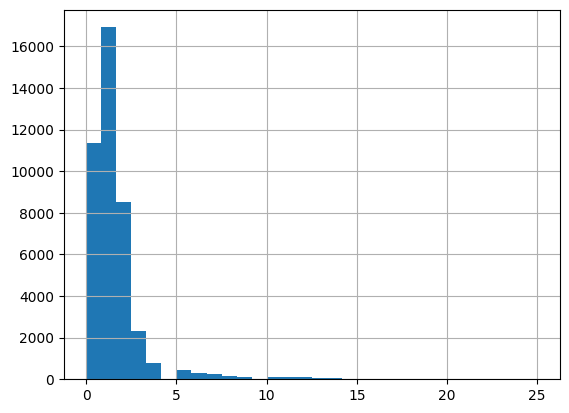

In [240]:
# Check 1: Distribution of time-difference

df["year_diff"] = df["GBAUJ_new"] - df["GABBJ_dem"]

print(df["year_diff"].describe())

df["year_diff"].hist(bins=30)

,count,mean,std,min,25%,50%,75%,max
GKAT_new,,,,,,,,
1020,31820.0,1.313639,1.685397,0.0,0.0,1.0,2.0,25.0
1030,3861.0,1.876198,2.179439,0.0,1.0,1.0,2.0,23.0
1040,1076.0,1.783457,2.367325,0.0,0.0,1.0,2.0,20.0
1060,4947.0,1.756418,3.050640,0.0,0.0,1.0,2.0,24.0


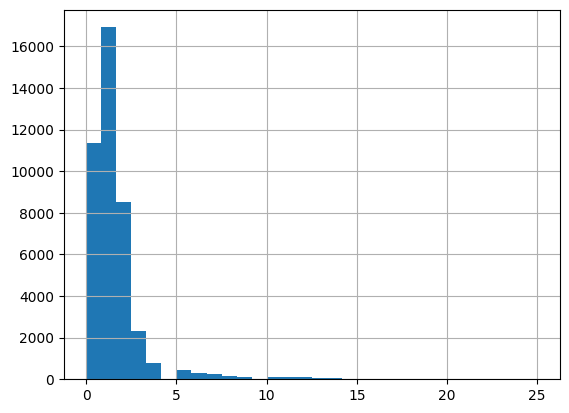

In [241]:
# Check 1: Distribution of time-difference (for residential new builds only)
# The above results seem valid but could be too short for residential construction projects
# Filtered to new residential projects only and see the distribution of time-difference

target_gkat = ["1020", "1030", "1040","1060"]

df_filtered = df[
    df["GKAT_new"].isin(target_gkat)
].copy()

df["GKAT_new"] = df["GKAT_new"].astype(str)

df_filtered["year_diff"].describe()
df_filtered["year_diff"].hist(bins=30)

df_filtered.groupby("GKAT_new")["year_diff"].describe()

In [242]:
# Check 2: Distance between demolished and replaced buildings

df["distance_m"] = gpd.GeoSeries(df["geometry_dem"]).distance(
    gpd.GeoSeries(df["geometry_new"])
)

In [243]:
stats = df["distance_m"].describe(percentiles=[0.9, 0.95, 0.99])
print(stats)

count    41704.000000
mean        22.382024
std        168.800963
min          0.000000
50%          6.420168
90%         28.549247
95%         46.673043
99%        253.160912
max      11636.707731
Name: distance_m, dtype: float64


In [244]:
df_valid = df[
    (df["distance_m"] < 30)
].copy()

# Filter on replaced_address 
replaced_address = df_valid[
    ["demolished_EGID", "replaced_EGID","GABBJ","GBAUJ","demolished_GKAT","replaced_GKAT","demolished_geometry","replaced_geometry"]
].drop_duplicates().copy()

In [245]:
replaced_address

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588)
2,1600096,191959225,2019,2022,1020,1020,POINT (2680089.783 1235037.699),POINT (2680092.956 1235041.657)
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441)
4,1600153,210239991,2018,2018,1030,1030,POINT (2679330.399 1235688.092),POINT (2679339.22 1235689.677)
...,...,...,...,...,...,...,...,...
41699,984449,191738431,2018,2019,1020,1020,POINT (2582580 1251218),POINT (2582579.204 1251219.129)
41700,400002736,191333590,2016,2016,1040,1020,POINT (2581689.519 1251208.929),POINT (2581688.812 1251209.383)
41701,983115,190161135,2007,2007,1020,1020,POINT (2574673 1258370),POINT (2574674.859 1258367.39)
41702,983116,190158413,2007,2007,1030,1020,POINT (2574697 1258398),POINT (2574702.028 1258394.897)


In [246]:
# Check 3: The distribution of matched demolished and replaced buildings category

gkat_dem_dist = df["GKAT_dem"].value_counts(normalize=True)
print(gkat_dem_dist)

1020    0.627398
1060    0.181997
1030    0.129700
1040    0.057980
nan     0.002925
Name: GKAT_dem, dtype: float64


In [247]:
gkat_new_dist = df["GKAT_new"].value_counts(normalize=True)
print(gkat_new_dist)

1020    0.762996
1060    0.118622
1030    0.092581
1040    0.025801
Name: GKAT_new, dtype: float64


In [248]:
gkat_transition_norm = pd.crosstab(
    df["GKAT_dem"],
    df["GKAT_new"],
    normalize="index"
)

print(gkat_transition_norm)

GKAT_new      1020      1030      1040      1060
GKAT_dem                                        
1020      0.913740  0.053430  0.009746  0.023084
1030      0.708634  0.221852  0.031059  0.038454
1040      0.500000  0.210505  0.144748  0.144748
1060      0.367852  0.097365  0.038999  0.495784
nan       0.639344  0.122951  0.057377  0.180328


#### 3.3 Approach 2: Matching Demolished Buildings AND Replaced Buildings Based On Entrances `geometry` 

- This process follows the procedure in the SPUR paper (Lutz, E., Kauer, F. and Kaufmann, D. (2023) Mehr Wohnraum für Alle?: Zonenplanänderungen, Bauaktivität, und Mietpreise im Kanton Zürich von 1996-2020 [application/pdf]. ETH Zurich, p. 36 p. Available at: https://doi.org/10.3929/ETHZ-B-000603242.) in identifying replacement buildings from GWR based on the coordinates of the entrances (under 15m)

In [250]:
# Entrance Coordinate Matching

matched = matched.merge(
    EIN_new[["geometry"]].rename(columns={"geometry": "geometry_new"}),
    left_on="index_new",
    right_index=True,
    how="left"
)

matched = matched.rename(columns={"geometry": "geometry_dem"})

In [251]:
matched

,EGID_dem,EDID_dem,EGAID_dem,DEINR_dem,DKODE_dem,DKODN_dem,DOFFADR_dem,Create_Date_dem,Update_Date_dem,ESID_dem,STROFFIZIEL_dem,DPLZ4_dem,DPLZZ_dem,DPLZNAME_dem,STRSP_dem,STRNAME_dem,STRNAMK_dem,STRINDX_dem,geometry_dem,GABBJ,GDEKT_dem,GDENAME_dem,GGDENR_dem,GKAT_dem,GKLAS_dem,GAREA_dem,GVOL_dem,GAZZI_dem,index_new,EGID_new,EDID_new,EGAID_new,DEINR_new,DKODE_new,DKODN_new,DOFFADR_new,Create_Date_new,Update_Date_new,ESID_new,STROFFIZIEL_new,DPLZ4_new,DPLZZ_new,DPLZNAME_new,STRSP_new,STRNAME_new,STRNAMK_new,STRINDX_new,GBAUJ,GDEKT_new,GDENAME_new,GGDENR_new,GKAT_new,GKLAS_new,GSTAT,GAREA_new,GVOL_new,GAZZI_new,geometry_new
0,1600049,0,100964842,26,2678759.510,1237302.438,0,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678759.51 1237302.438),2019,ZH,Aeugst am Albis,1,1040,NaN,NaN,NaN,NaN,158,210220446,0,102397146,26,2678765.168,1237309.890,1,2018-03-08,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,2020,ZH,Aeugst am Albis,1,1020,1122,1004,219,NaN,19,POINT (2678765.168 1237309.89)
1,1600073,0,100964864,18,2678905.122,1237289.769,0,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,POINT (2678905.122 1237289.769),2017,ZH,Aeugst am Albis,1,1020,1110,NaN,NaN,NaN,149,210215670,0,102288064,18,2678918.198,1237293.467,1,2016-12-14,2024-07-29,10000508,1,8914,2,Aeugstertal,9901,Mülibergstrasse,Mülibergstr.,Mül,2018,ZH,Aeugst am Albis,1,1020,1110,1004,869,NaN,NaN,POINT (2678918.198 1237293.467)
2,1600096,0,100962991,4,2680086.649,1235039.234,0,2016-12-14,2025-11-13,10000503,1,8914,0,Aeugst am Albis,9901,Weid,Weid,Wei,POINT (2680086.649 1235039.234),2019,ZH,Aeugst am Albis,1,1020,1110,160,NaN,NaN,4,191959225,1,103086364,4,2680096.127,1235047.236,0,2021-08-05,2025-11-13,10000503,1,8914,0,Aeugst am Albis,9901,Weid,Weid,Wei,2022,ZH,Aeugst am Albis,1,1020,1110,1004,210,1121,NaN,POINT (2680096.127 1235047.236)
4,1600128,0,100964442,17,2679335.465,1235433.742,0,2016-12-14,2024-07-29,10075231,1,8914,0,Aeugst am Albis,9901,Büelstrasse,Büelstr.,Büe,POINT (2679335.465 1235433.742),2017,ZH,Aeugst am Albis,1,1020,1110,NaN,NaN,NaN,146,210215058,0,102243776,17,2679335.465,1235433.742,1,2016-12-14,2024-07-29,10075231,1,8914,0,Aeugst am Albis,9901,Büelstrasse,Büelstr.,Büe,2018,ZH,Aeugst am Albis,1,1020,1122,1004,170,NaN,NaN,POINT (2679335.465 1235433.742)
6,1600148,0,100964462,38,2679450.000,1235580.000,0,2016-12-14,2024-07-29,10075232,1,8914,0,Aeugst am Albis,9901,Dorfstrasse,Dorfstr.,Dor,POINT (2679450 1235580),2017,ZH,Aeugst am Albis,1,1020,1121,NaN,NaN,NaN,142,210213999,0,102179313,7a,2679451.032,1235573.018,1,2016-12-14,2024-07-29,10106386,1,8914,0,Aeugst am Albis,9901,Chilenacherweg,Chilenacherweg,Chi,2017,ZH,Aeugst am Albis,1,1020,1121,1004,252,NaN,NaN,POINT (2679451.032 1235573.018)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114357,502204093,0,103185347,4a.1,2581352.965,1251369.942,0,2021-11-23,2024-12-18,10099590,1,2953,2,Fregiécourt,9903,Route de la Montoie,Rte de la Montoie,Mon,POINT (2581352.965 1251369.942),2023,JU,La Baroche,6810,1060,1278,4,NaN,NaN,558554,502204092,0,103185356,4a.2,2581349.273,1251369.593,0,2021-11-23,2024-12-18,10099590,1,2953,2,Fregiécourt,9903,Route de la Montoie,Rte de la Montoie,Mon,2001,JU,La Baroche,6810,1060,1278,1007,10,NaN,NaN,POINT (2581349.273 1251369.593)
114357,502204093,0,103185347,4a.1,2581352.965,1251369.942,0,2021-11-23,2024-12-18,10099590,1,2953,2,Fregiécourt,9903,Route de la Montoie,Rte de la Montoie,Mon,POINT (2581352.965 1251369.942),2023,JU,La Baroche,6810,1060,1278,4,NaN,NaN,558555,502204093,0,103185347,4a.1,2581352.965,1251369.942,0,2021-11-23,2024-12-18,10099590,1,2953,2,Fregiécourt,9903,Route de la Montoie,Rte de la Montoie,Mon,2001,JU,La Baroche,6810,1060,1278,1007,4,NaN,NaN,POINT (258135

In [252]:
# Temporal filter

matched = matched.loc[
    matched["GBAUJ"] >= matched["GABBJ"]
].copy()

In [253]:
# Drop entrance features for clarity

matched_15m = matched[
    ["EGID_dem", "EGID_new", "GABBJ", "GBAUJ"]
].drop_duplicates().copy()

In [254]:
matched_15m

,EGID_dem,EGID_new,GABBJ,GBAUJ
0,1600049,210220446,2019,2020
1,1600073,210215670,2017,2018
2,1600096,191959225,2019,2022
4,1600128,210215058,2017,2018
6,1600148,210213999,2017,2017
...,...,...,...,...
114345,984071,191489171,2015,2016
114346,984449,191738431,2018,2019
114347,400002736,191333590,2016,2016
114355,502204076,192034207,2023,2024


In [255]:
# Attach building geometry

geb_dem = GEB_demolished[["EGID", "GKAT", "geometry"]].rename(columns={
    "EGID": "EGID_dem",
    "GKAT": "demolished_GKAT",
    "geometry": "demolished_geometry"
})

geb_new = GEB_new[["EGID", "GKAT", "geometry"]].rename(columns={
    "EGID": "EGID_new",
    "GKAT": "replaced_GKAT",
    "geometry": "replaced_geometry"
})

replaced_entrances = (
    matched_15m
    .merge(geb_dem, on="EGID_dem", how="left")
    .merge(geb_new, on="EGID_new", how="left")
    .rename(columns={
        "EGID_dem": "demolished_EGID",
        "EGID_new": "replaced_EGID"
    })
    [
        [
            "demolished_EGID",
            "replaced_EGID",
            "GABBJ",
            "GBAUJ",
            "demolished_GKAT",
            "replaced_GKAT",
            "demolished_geometry",
            "replaced_geometry"
        ]
    ]
    .drop_duplicates()
    .copy()
)

In [256]:
replaced_entrances

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588)
2,1600096,191959225,2019,2022,1020,1020,POINT (2680089.783 1235037.699),POINT (2680092.956 1235041.657)
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441)
4,1600148,210213999,2017,2017,1020,1020,POINT (2679450.508 1235579.491),POINT (2679452.443 1235576.643)
...,...,...,...,...,...,...,...,...
43899,984071,191489171,2015,2016,1020,1020,POINT (2579867 1253473),POINT (2579869.125 1253474.43)
43900,984449,191738431,2018,2019,1020,1020,POINT (2582580 1251218),POINT (2582579.204 1251219.129)
43901,400002736,191333590,2016,2016,1040,1020,POINT (2581689.519 1251208.929),POINT (2581688.812 1251209.383)
43902,502204076,192034207,2023,2024,1060,1020,POINT (2581791.21 1251246.926),POINT (2581784.858 1251256.544)


In [257]:
# df for inspection

# Demolished 
df_2 = replaced_entrances.merge(
    GEB_sub.add_suffix("_dem"),
    left_on="demolished_EGID",
    right_on="EGID_dem",
    how="left"
)

# Replaced
df_2 = df_2.merge(
    GEB_sub.add_suffix("_new"),
    left_on="replaced_EGID",
    right_on="EGID_new",
    how="left"
)

count    43904.000000
mean         1.328649
std          1.576460
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         24.000000
Name: year_diff, dtype: float64


<Axes: >

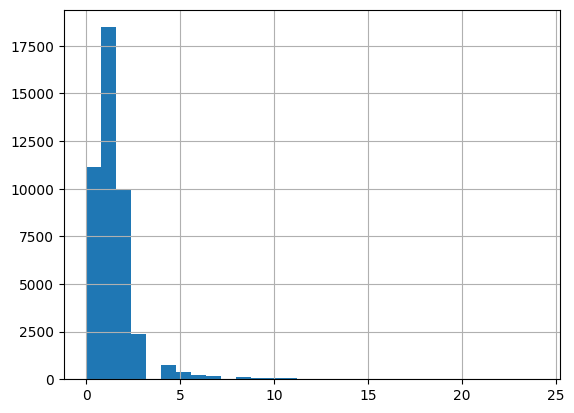

In [258]:
# Check 1: Distribution of time-difference

df_2["year_diff"] = df_2["GBAUJ_new"] - df_2["GABBJ_dem"]

print(df_2["year_diff"].describe())

df_2["year_diff"].hist(bins=30)

In [259]:
# Check 2: Distance between demolished and replaced buildings

df_2["distance_m"] = gpd.GeoSeries(df_2["geometry_dem"]).distance(
    gpd.GeoSeries(df_2["geometry_new"])
)

In [260]:
stats = df_2["distance_m"].describe(percentiles=[0.9, 0.95, 0.99])
print(stats)

count    43904.000000
mean         8.186675
std          8.513732
min          0.000000
50%          6.727581
90%         15.170093
95%         18.670874
99%         34.171302
max        314.682520
Name: distance_m, dtype: float64


In [261]:
df_2_valid = df_2[
    (df_2["distance_m"] < 30)
].copy()

# Filter on replaced_address 
replaced_entrances = df_2_valid[
    ["demolished_EGID", "replaced_EGID","GABBJ","GBAUJ","demolished_GKAT","replaced_GKAT","demolished_geometry","replaced_geometry"]
].drop_duplicates().copy()

In [262]:
replaced_entrances

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588)
2,1600096,191959225,2019,2022,1020,1020,POINT (2680089.783 1235037.699),POINT (2680092.956 1235041.657)
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441)
4,1600148,210213999,2017,2017,1020,1020,POINT (2679450.508 1235579.491),POINT (2679452.443 1235576.643)
...,...,...,...,...,...,...,...,...
43899,984071,191489171,2015,2016,1020,1020,POINT (2579867 1253473),POINT (2579869.125 1253474.43)
43900,984449,191738431,2018,2019,1020,1020,POINT (2582580 1251218),POINT (2582579.204 1251219.129)
43901,400002736,191333590,2016,2016,1040,1020,POINT (2581689.519 1251208.929),POINT (2581688.812 1251209.383)
43902,502204076,192034207,2023,2024,1060,1020,POINT (2581791.21 1251246.926),POINT (2581784.858 1251256.544)


In [263]:
# Check 3: The distribution of matched demolished and replaced buildings category

gkat_dem_dist = df_2["GKAT_dem"].value_counts(normalize=True)
print(gkat_dem_dist)

1020    0.579355
1060    0.279246
1030    0.100105
1040    0.039655
nan     0.001640
Name: GKAT_dem, dtype: float64


In [264]:
gkat_new_dist = df_2["GKAT_new"].value_counts(normalize=True)
print(gkat_new_dist)

1020    0.757676
1060    0.150943
1030    0.074093
1040    0.017288
Name: GKAT_new, dtype: float64


In [265]:
gkat_transition_norm = pd.crosstab(
    df_2["GKAT_dem"],
    df_2["GKAT_new"],
    normalize="index"
)

print(gkat_transition_norm)

GKAT_new      1020      1030      1040      1060
GKAT_dem                                        
1020      0.875098  0.045919  0.006801  0.072181
1030      0.708532  0.197497  0.024573  0.069397
1040      0.542217  0.190695  0.118323  0.148765
1060      0.563622  0.071697  0.022186  0.342496
nan       0.527778  0.083333  0.000000  0.388889


#### 3.4 Cross-checking Two Approaches 

- `len(replaced_address)=37797`
- `len(replaced_entrances)=43333`

In [277]:
key_cols = ["demolished_EGID", "replaced_EGID"]

print(replaced_address.duplicated(subset=key_cols).sum())
print(replaced_entrances.duplicated(subset=key_cols).sum())

0
0


In [278]:
addr = replaced_address.drop_duplicates(subset=key_cols).copy()
entr = replaced_entrances.drop_duplicates(subset=key_cols).copy()

In [282]:
both = addr.merge(
    entr[key_cols],
    on=key_cols,
    how="inner"
).copy()

only_address = addr.merge(
    entr[key_cols],
    on=key_cols,
    how="left",
    indicator=True
)

only_address = only_address[
    only_address["_merge"] == "left_only"
].drop(columns="_merge").copy()

only_entrances = entr.merge(
    addr[key_cols],
    on=key_cols,
    how="left",
    indicator=True
)

only_entrances = only_entrances[
    only_entrances["_merge"] == "left_only"
].drop(columns="_merge").copy()

In [283]:
print(len(addr))
print(len(entr))
print(len(both))
print(len(only_address))
print(len(only_entrances))

print(len(both) + len(only_address) == len(addr))
print(len(both) + len(only_entrances) == len(entr))

37797
43333
22017
15780
21316
True
True


In [284]:
# One combined non-overlapping table

replaced = pd.concat(
    [
        addr,
        only_entrances
    ],
    ignore_index=True
).drop_duplicates(subset=key_cols).copy()

In [285]:
replaced

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588)
2,1600096,191959225,2019,2022,1020,1020,POINT (2680089.783 1235037.699),POINT (2680092.956 1235041.657)
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441)
4,1600153,210239991,2018,2018,1030,1030,POINT (2679330.399 1235688.092),POINT (2679339.22 1235689.677)
...,...,...,...,...,...,...,...,...
59108,986385,191951469,2021,2021,1020,1060,POINT (2577938.492 1255880.144),POINT (2577928.885 1255887.404)
59109,504043694,192088395,2024,2024,1060,1060,POINT (2567173.443 1248711.94),POINT (2567176.26 1248721.183)
59110,983781,192034207,2023,2024,1020,1020,POINT (2581782.837 1251269.159),POINT (2581784.858 1251256.544)
59111,983782,192034204,2018,2024,1060,1020,POINT (2581786.007 1251256.315),POINT (2581783.058 1251266.894)


#### 3.5 Matching Quality 

- 1 to 1 matching: Keep
- 1 to many matching
- Many to 1 matching
- Many to many matching

In [286]:
# Define the function for identifying different forms of matching

def classify_match_type(df):
    dem_counts = (
        df.groupby("demolished_EGID")["replaced_EGID"]
        .nunique()
        .rename("n_replaced_per_dem")
    )

    rep_counts = (
        df.groupby("replaced_EGID")["demolished_EGID"]
        .nunique()
        .rename("n_demolished_per_replaced")
    )

    out = df.merge(dem_counts, on="demolished_EGID", how="left")
    out = out.merge(rep_counts, on="replaced_EGID", how="left")

    # classify
    out["match_type"] = "1_to_1"

    out.loc[
        (out["n_replaced_per_dem"] > 1) & (out["n_demolished_per_replaced"] == 1),
        "match_type"
    ] = "1_to_many"

    out.loc[
        (out["n_replaced_per_dem"] == 1) & (out["n_demolished_per_replaced"] > 1),
        "match_type"
    ] = "many_to_1"

    out.loc[
        (out["n_replaced_per_dem"] > 1) & (out["n_demolished_per_replaced"] > 1),
        "match_type"
    ] = "many_to_many"

    return out

In [290]:
# Pair-wise matching

replaced_diag = classify_match_type(replaced)

print(replaced_diag["match_type"].value_counts())

1_to_1          34634
1_to_many        9930
many_to_1        9384
many_to_many     5165
Name: match_type, dtype: int64


In [288]:
# replaced.to_csv("replacement_year_non_1_1_matching.csv", index=False)

#### 3.6 Quartier-checking (Zurich Canton Only)

- **Quartier Spatial Checking**: As the matching quality is low (i.e., quite a lot of many to 1, 1 to many, many to many etc). Although they can be realistically possible, here we'll verify whether the pair is a true pair by using the quartier map as the unit bounding each pair possible. However, the unit differs among cantons, so only more verified zurich canton-only replaced buildings will be prepared here.

- **One (demolished) to Many (replaced)**: There are 11387 unique demolished buildings in the Canton in this time. 1855 of them appear more than once, which means the demolished building is replaced by multiple new buildings. Upon inspection of the extreme values, most of the extreme values belong to non-residential buildings replaced by non-residential buildings. Among residential buildings, the year of construction of the multiple replaced buildings to a single demolished building are almost all in the same year. Plus each pair is all from the same quartier, plus year of demolition must be before year of construction, this direction should be clean now.

- **Many (demolished) to One (replaced)**: There are 10774 unique replaced buildings in the Canton in this time. 2273 of them appear more than once, which means there are multiple buildings demolished for one single new building, which is possible. Upon inspection of the extreme values, the year of destruction of the multiple demolished buildings to a single replaced building is almost all in the same. Plus each pair is all from the same quartier, plus year of demolition must be before year of construction, this direction should be clean now.

In [293]:
# From replaced, keep only the rows where both demolished and replaced buildings are in the Canton of Zurich

geb_kanton = GEB[["EGID", "GDEKT"]].drop_duplicates().copy()
geb_kanton["EGID"] = pd.to_numeric(geb_kanton["EGID"], errors="coerce")

replaced_zh = replaced.copy()
replaced_zh["demolished_EGID"] = pd.to_numeric(replaced_zh["demolished_EGID"], errors="coerce")
replaced_zh["replaced_EGID"]   = pd.to_numeric(replaced_zh["replaced_EGID"], errors="coerce")
replaced_zh = replaced_zh.dropna(subset=["demolished_EGID", "replaced_EGID"])

# merge canton for demolished_EGID
replaced_zh = replaced_zh.merge(
    geb_kanton.rename(columns={
        "EGID": "demolished_EGID",
        "GDEKT": "demolished_GDEKT"
    }),
    on="demolished_EGID",
    how="left"
)

# merge canton for replaced_EGID
replaced_zh = replaced_zh.merge(
    geb_kanton.rename(columns={
        "EGID": "replaced_EGID",
        "GDEKT": "replaced_GDEKT"
    }),
    on="replaced_EGID",
    how="left"
)

# keep only rows where both are in Zurich
replaced_zh = replaced_zh[
    (replaced_zh["demolished_GDEKT"] == "ZH") &
    (replaced_zh["replaced_GDEKT"] == "ZH")
].copy()

replaced_zh = replaced_zh.drop(columns=["demolished_GDEKT", "replaced_GDEKT"])

In [294]:
print("before:", len(replaced))
print("after:", len(replaced_zh))

before: 59113
after: 14466


In [295]:
replaced_zh

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588)
2,1600096,191959225,2019,2022,1020,1020,POINT (2680089.783 1235037.699),POINT (2680092.956 1235041.657)
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441)
4,1600153,210239991,2018,2018,1030,1030,POINT (2679330.399 1235688.092),POINT (2679339.22 1235689.677)
...,...,...,...,...,...,...,...,...
44288,210253341,210217240,2018,2020,1060,1020,POINT (2704132.024 1266446.625),POINT (2704116.984 1266448.095)
44289,210253341,210217244,2018,2020,1060,1020,POINT (2704132.024 1266446.625),POINT (2704116.355 1266453.972)
44290,210253566,192013896,2024,2024,1060,1020,POINT (2701985.918 1264238.311),POINT (2701988.265 1264235.759)
44291,210253615,192031633,2021,2024,1060,1060,POINT (2701141.323 1265015.298),POINT (2701141.901 1265022.088)


In [299]:
replaced_zh.to_csv("replacement_year_ZH_unchecked.csv", index=False)

In [296]:
# Load the quartier shapes

quartier = gpd.read_file("Quartieranalyse_-OGD.gpkg")

In [297]:
quartier

,QID,GQID,U_BFSNR,U_GEMEINDE,U_REGION,U_FLAECHE,U_ZONE_KT,U_EINW,U_BESCH,U_GFL,U_GFLR,U_AG,U_OEV_GKL,N_EINW_HA,N_BESCH_HA,N_HH,N_HH_KIND,N_HH_SPFAM,N_HH_SPPE,B_FL_BB,B_GEBAEUDE,B_EFH,B_MFH,B_STWE,B_BP_VOR45,B_BP_45_75,B_BP_76_00,B_BP_N_00,B_GEB_PROJ,B_GEB_NEU5,B_GEBV_AB5,EINF,STICHTAG,N_NUTZ_HA,PDF,SHAPE.AREA,SHAPE.LEN,geometry
0,32473.0,0,91,Niederweningen,Zürcher Unterland,6858,W2b,45.0,NaN,2117,1506.0,58.0,E,66.0,NaN,14.0,42.9,21.4,7.1,1389,17,58.8,17.6,0.0,0.0,17.6,35.3,35.3,0,0,0,wohnzone_bis_W2,31.12.2025,66,https://www.web.statistik.zh.ch/kunden/arbeits...,6857.914348,339.331650,"POLYGON ((2670368.843 1261891.136, 2670347.474..."
1,32462.0,0,91,Niederweningen,Zürcher Unterland,5330,W2b,15.0,7.0,1589,1207.0,57.0,E,28.0,13.0,6.0,33.3,16.7,0.0,1082,8,75.0,12.5,0.0,12.5,0.0,50.0,25.0,0,0,0,wohnzone_bis_W2,31.12.2025,41,https://www.web.statistik.zh.ch/kunden/arbeits...,5330.470180,586.694383,"POLYGON ((2670404.584 1261924.911, 2670404.401..."
2,32508.0,0,91,Niederweningen,Zürcher Unterland,19704,WG2d,33.0,0.0,2043,11930.0,15.0,D,17.0,0.0,17.0,17.6,0.0,17.6,1093,9,22.2,33.3,66.7,22.2,0.0,11.1,55.6,0,0,0,mischzone,31.12.2025,17,https://www.web.statistik.zh.ch/kunden/arbeits...,19703.830151,1173.151916,"POLYGON ((2670633.185 1262280.767, 2670666.485..."
3,32487.0,0,91,Niederweningen,Zürcher Unterland,5084,W2d,58.0,0.0,2127,1607.0,57.0,E,114.0,0.0,24.0,20.8,4.2,8.3,1207,6,0.0,100.0,0.0,0.0,100.0,0.0,0.0,0,0,0,wohnzone_bis_W2,31.12.2025,114,https://www.web.statistik.zh.ch/kunden/arbeits...,5084.030665,501.915431,"POLYGON ((2670514.364 1262607.615, 2670519.525..."
4,32529.0,0,91,Niederweningen,Zürcher Unterland,388,K,0.0,0.0,113,0.0,100.0,D,0.0,0.0,0.0,0.0,0.0,0.0,107,2,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0,0,0,mischzone,31.12.2025,0,https://www.web.statistik.zh.ch/kunden/arbeits...,387.652973,78.813594,"POLYGON ((2670692.645 1261850.643, 2670683.405..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32345,1207.0,0,114,Fischenthal,Zürcher Oberland,1031,W2a,NaN,NaN,124,259.0,32.0,F,NaN,NaN,NaN,NaN,NaN,NaN,112,2,50.0,0.0,0.0,0.0,50.0,0.0,0.0,0,0,0,wohnzone_bis_W2,31.12.2025,0,https://www.web.statistik.zh.ch/kunden/arbeits...,1031.423275,154.420320,"POLYGON ((2713040.613 1244879.807, 2713053.136..."
32346,1284.0,0,114,Fischenthal,Zürcher Oberland,2387,K,12.0,0.0,809,6.0,99.0,D,50.0,0.0,4.0,50.0,0.0,0.0,532,5,40.0,20.0,0.0,20.0,0.0,80.0,0.0,0,0,0,mischzone,31.12.2025,50,https://www.web.statistik.zh.ch/kunden/arbeits...,2386.644090,203.495490,"POLYGON ((2712959.361 1245480.149, 2712949.539..."
32347,1288.0,0,114,Fischenthal,Zürcher Oberland,2631,K,NaN,0.0,563,0.0,100.0,D,NaN,0.0,NaN,NaN,NaN,NaN,423,2,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0,0,0,mischzone,31.12.2025,0,https://www.web.statistik.zh.ch/kunden/arbeits...,2630.627690,211.120505,"POLYGON ((2713096.403 1245539.242, 2713102.144..."
32348,2653.0,0,120,Wald,Zürcher Oberland,249,W2c,0.0,0.0,0,157.0,0.0,schlechter als F,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,wohnzone_bis_W2,31.12.2025,0,https://www.web.statistik.zh.ch/kunden/arbeits...,248.597580,300.636847,"POLYGON ((2713565.329 1236374.345, 2713567.002..."


In [301]:
from shapely import wkt
from shapely.geometry.base import BaseGeometry

# WKT to real geo

def to_geom(x):
    if pd.isna(x):
        return None
    if isinstance(x, BaseGeometry):
        return x
    if isinstance(x, str):
        return wkt.loads(x)
    return None

pairs = replaced_zh.reset_index(drop=True).copy()
pairs["pair_id"] = pairs.index

pairs["demolished_geometry"] = pairs["demolished_geometry"].apply(to_geom)
pairs["replaced_geometry"] = pairs["replaced_geometry"].apply(to_geom)

dem = gpd.GeoDataFrame(
    pairs[["pair_id", "demolished_geometry"]].copy(),
    geometry="demolished_geometry",
    crs="EPSG:2056"
)

rep = gpd.GeoDataFrame(
    pairs[["pair_id", "replaced_geometry"]].copy(),
    geometry="replaced_geometry",
    crs="EPSG:2056"
)

In [302]:
# Keep only the quartier polygon
quartier_cols = ["geometry"]
quartier_sub = quartier[quartier_cols].copy()

# Assign each demolished point to a quartier polygon
dem_join = gpd.sjoin(
    dem,
    quartier_sub,
    how="left",
    predicate="within"
)

# Assign each replaced point to a quartier polygon
rep_join = gpd.sjoin(
    rep,
    quartier_sub,
    how="left",
    predicate="within"
)

In [304]:
dem_q = dem_join[["pair_id", "index_right"]].rename(
    columns={"index_right": "dem_quartier_id"}
)

rep_q = rep_join[["pair_id", "index_right"]].rename(
    columns={"index_right": "rep_quartier_id"}
)

# Combine demolished and replaced results
quartier_check = dem_q.merge(
    rep_q,
    on="pair_id",
    how="outer"
)

# Check whether both are inside a quartier and the same one
quartier_check["same_quartier"] = (
    quartier_check["dem_quartier_id"].notna() &
    quartier_check["rep_quartier_id"].notna() &
    (quartier_check["dem_quartier_id"] == quartier_check["rep_quartier_id"])
)

quartier_check["same_quartier"].value_counts(dropna=False)

True     13833
False      633
Name: same_quartier, dtype: int64

In [305]:
replaced_zh_checked = pairs.merge(
    quartier_check,
    on="pair_id",
    how="left"
)

In [306]:
replaced_zh_checked = replaced_zh_checked[
    replaced_zh_checked["same_quartier"]
].copy()

In [308]:
print("all pairs:", len(pairs))
print("same quartier:", len(replaced_zh_checked))

all pairs: 14466
same quartier: 13833


In [309]:
replaced_zh_checked

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry,pair_id,dem_quartier_id,rep_quartier_id,same_quartier
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047),0,12696.0,12696.0,True
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588),1,8699.0,8699.0,True
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441),3,4672.0,4672.0,True
4,1600153,210239991,2018,2018,1030,1030,POINT (2679330.399 1235688.092),POINT (2679339.22 1235689.677),4,8751.0,8751.0,True
5,1600187,191962310,2023,2025,1020,1020,POINT (2679802.455 1235896.914),POINT (2679801.5 1235899),5,20858.0,20858.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
14456,210253054,191957885,2022,2024,1060,1020,POINT (2702426.877 1265912.498),POINT (2702421.536 1265897.953),14456,7652.0,7652.0,True
14457,210253107,191885554,2021,2022,1060,1020,POINT (2700878.879 1265051.288),POINT (2700874.136 1265052.485),14457,15666.0,15666.0,True
14458,210253156,192086995,2021,2024,1060,1060,POINT (2701157.326 1265015.967),POINT (2701171.121 1265014.881),14458,11633.0,11633.0,True
14464,210253615,192031633,2021,2024,1060,1060,POINT (2701141.323 1265015.298),POINT (2701141.901 1265022.088),14464,11633.0,11633.0,True


In [315]:
replaced_zh_checked["demolished_EGID"].nunique()

11387

In [319]:
replaced_zh_checked["replaced_EGID"].nunique()

10774

In [310]:
replaced_zh_checked["demolished_EGID"].duplicated().any()

True

In [316]:
dup_counts_demolished = replaced_zh_checked["demolished_EGID"].value_counts()

dup_counts_demolished.head()

210274999    9
2313905      7
146286       6
106232       6
146271       6
Name: demolished_EGID, dtype: Int64

In [317]:
dup_dem_demolished = dup_counts_demolished[dup_counts_demolished > 1]

# Number of EGIDs with duplicates
len(dup_dem_demolished)  

1855

In [318]:
dup_dem_demolished.value_counts().sort_index()

2    1449
3     276
4      91
5      27
6      10
7       1
9       1
Name: demolished_EGID, dtype: Int64

In [322]:
top_dem = dup_counts_demolished.head(8).index

extreme_rows = replaced_zh_checked[
    replaced_zh_checked["demolished_EGID"].isin(top_dem)
].copy()

extreme_rows.sort_values(["demolished_EGID", "GBAUJ"])

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry,pair_id,dem_quartier_id,rep_quartier_id,same_quartier
14217,54204,191964849,2019,2021,1020,1060,POINT (2688771 1234111),POINT (2688776.332 1234092.488),14217,18279.0,18279.0,True
14218,54204,210279380,2019,2021,1020,1020,POINT (2688771 1234111),POINT (2688783.903 1234098.496),14218,18279.0,18279.0,True
14219,54204,191964847,2019,2021,1020,1060,POINT (2688771 1234111),POINT (2688772.674 1234097.098),14219,18279.0,18279.0,True
14220,54204,210279378,2019,2021,1020,1020,POINT (2688771 1234111),POINT (2688780.245 1234103.106),14220,18279.0,18279.0,True
14221,54204,191964845,2019,2021,1020,1060,POINT (2688771 1234111),POINT (2688768.93 1234101.818),14221,18279.0,18279.0,True
14222,54204,210279381,2019,2021,1020,1020,POINT (2688771 1234111),POINT (2688776.49 1234107.841),14222,18279.0,18279.0,True
10811,106232,210239054,2020,2020,1020,1020,POINT (2690310.01 1264079.71),POINT (2690308.937 1264072.874),10811,2278.0,2278.0,True
10812,106232,210239055,2020,2020,1020,1020,POINT (2690310.01 1264079.71),POINT (2690302.807 1264073.627),10812,2278.0,2278.0,True
10813,106232,210239056,2020,2020,1020,1020,POINT (2690310.01 1264079.71),POINT (2690317.255 1264087.998),10813,2278.0,2278.0,True
10814,106232,210239058,2020,2020,1020,1020,POINT (2690310.01 1264079.71),POINT (2690311.091 1264088.034),10814,2278.0,2278.0,True


In [323]:
dup_counts_replaced = replaced_zh_checked["replaced_EGID"].value_counts()

dup_counts_replaced.head()

210193229    13
210201082    10
210201081    10
210222038     8
201028670     8
Name: replaced_EGID, dtype: Int64

In [324]:
dup_dem_replaced = dup_counts_replaced[dup_counts_replaced > 1]

# Number of EGIDs with duplicates
len(dup_dem_replaced)  

2273

In [325]:
dup_dem_replaced.value_counts().sort_index()

2     1762
3      337
4      111
5       45
6       12
7        1
8        2
10       2
13       1
Name: replaced_EGID, dtype: Int64

In [327]:
top_dem = dup_dem_replaced.head(5).index

extreme_rows = replaced_zh_checked[
    replaced_zh_checked["replaced_EGID"].isin(top_dem)
].copy()

extreme_rows.sort_values(["replaced_EGID", "GABBJ"])

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry,pair_id,dem_quartier_id,rep_quartier_id,same_quartier
5297,120257,201028670,2007,2008,1020,1020,POINT (2675997.725 1250726.785),POINT (2675995.994 1250721.465),5297,12442.0,12442.0,True
5298,120293,201028670,2007,2008,1020,1020,POINT (2675997.725 1250726.785),POINT (2675995.994 1250721.465),5298,12442.0,12442.0,True
11556,120246,201028670,2007,2008,1020,1020,POINT (2676000.955 1250719.901),POINT (2675995.994 1250721.465),11556,12442.0,12442.0,True
11557,120247,201028670,2007,2008,1020,1020,POINT (2676000.955 1250719.901),POINT (2675995.994 1250721.465),11557,12442.0,12442.0,True
11558,120248,201028670,2007,2008,1020,1020,POINT (2676000.955 1250719.901),POINT (2675995.994 1250721.465),11558,12442.0,12442.0,True
11560,120266,201028670,2007,2008,1020,1020,POINT (2676000.955 1250719.901),POINT (2675995.994 1250721.465),11560,12442.0,12442.0,True
11561,120275,201028670,2007,2008,1020,1020,POINT (2676000.955 1250719.901),POINT (2675995.994 1250721.465),11561,12442.0,12442.0,True
11564,120287,201028670,2007,2008,1020,1020,POINT (2676000.955 1250719.901),POINT (2675995.994 1250721.465),11564,12442.0,12442.0,True
11253,1160914,210193229,2010,2012,1060,1060,POINT (2694200.214 1262341.951),POINT (2694186.417 1262344.647),11253,2689.0,2689.0,True
11254,1160915,210193229,2010,2012,1060,1060,POINT (2694200.214 1262341.951),POINT (2694186.417 1262344.647),11254,2689.0,2689.0,True


#### 3.7 Cleaning (`replaced_zh_checked`)


In [328]:
replaced_zh_checked

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry,pair_id,dem_quartier_id,rep_quartier_id,same_quartier
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047),0,12696.0,12696.0,True
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588),1,8699.0,8699.0,True
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441),3,4672.0,4672.0,True
4,1600153,210239991,2018,2018,1030,1030,POINT (2679330.399 1235688.092),POINT (2679339.22 1235689.677),4,8751.0,8751.0,True
5,1600187,191962310,2023,2025,1020,1020,POINT (2679802.455 1235896.914),POINT (2679801.5 1235899),5,20858.0,20858.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
14456,210253054,191957885,2022,2024,1060,1020,POINT (2702426.877 1265912.498),POINT (2702421.536 1265897.953),14456,7652.0,7652.0,True
14457,210253107,191885554,2021,2022,1060,1020,POINT (2700878.879 1265051.288),POINT (2700874.136 1265052.485),14457,15666.0,15666.0,True
14458,210253156,192086995,2021,2024,1060,1060,POINT (2701157.326 1265015.967),POINT (2701171.121 1265014.881),14458,11633.0,11633.0,True
14464,210253615,192031633,2021,2024,1060,1060,POINT (2701141.323 1265015.298),POINT (2701141.901 1265022.088),14464,11633.0,11633.0,True


In [329]:
type(replaced_zh_checked)

pandas.core.frame.DataFrame

In [330]:
replaced_zh_checked.columns

Index(['demolished_EGID', 'replaced_EGID', 'GABBJ', 'GBAUJ', 'demolished_GKAT',
       'replaced_GKAT', 'demolished_geometry', 'replaced_geometry', 'pair_id',
       'dem_quartier_id', 'rep_quartier_id', 'same_quartier'],
      dtype='object')

In [331]:
cols = [
    'demolished_EGID', 'replaced_EGID', 'GABBJ', 'GBAUJ',
    'demolished_GKAT', 'replaced_GKAT',
    'demolished_geometry', 'replaced_geometry'
]

replaced_zh_checked = replaced_zh_checked[cols].copy()

In [332]:
replaced_zh_checked

,demolished_EGID,replaced_EGID,GABBJ,GBAUJ,demolished_GKAT,replaced_GKAT,demolished_geometry,replaced_geometry
0,1600049,210220446,2019,2020,1040,1020,POINT (2678759.51 1237302.438),POINT (2678758.162 1237309.047)
1,1600073,210215670,2017,2018,1020,1020,POINT (2678905.122 1237289.769),POINT (2678925.507 1237308.588)
3,1600128,210215058,2017,2018,1020,1020,POINT (2679335.465 1235433.742),POINT (2679338.426 1235426.441)
4,1600153,210239991,2018,2018,1030,1030,POINT (2679330.399 1235688.092),POINT (2679339.22 1235689.677)
5,1600187,191962310,2023,2025,1020,1020,POINT (2679802.455 1235896.914),POINT (2679801.5 1235899)
...,...,...,...,...,...,...,...,...
14456,210253054,191957885,2022,2024,1060,1020,POINT (2702426.877 1265912.498),POINT (2702421.536 1265897.953)
14457,210253107,191885554,2021,2022,1060,1020,POINT (2700878.879 1265051.288),POINT (2700874.136 1265052.485)
14458,210253156,192086995,2021,2024,1060,1060,POINT (2701157.326 1265015.967),POINT (2701171.121 1265014.881)
14464,210253615,192031633,2021,2024,1060,1060,POINT (2701141.323 1265015.298),POINT (2701141.901 1265022.088)


In [333]:
# replaced_zh_checked.to_csv("replacement_year_ZH_checked.csv", index=False)

### 4. Soft Densification

#### 4.1 Type 1: Joining/Dividing Dwellings

- Rennovation year: Many are NaN
- Proxy for densification unchecked: Not sure if joining or dividing dwellings or other sorts of rennovation. Need to use the number of dwellings/habitable rooms from BDS before/after the renovation year or across the period to see if there is an increase.
- **Easier alternative?**: Just use the EGID (matching BDS based on geo-coordinate) with the increase on the number of dwellings from the longitudinal BDS. This can be considered together with extension/change of purpose. See below.

In [342]:
ARB["PINNUMB"].dtype

dtype('O')

In [343]:
arb_sub = ARB[ARB["PINNUMB"] == "1"].copy()

In [344]:
arb_sub

,EPROID,ARBID,EGID,PARTAB,PENSAN,PHEIZSAN,PINNUMB,PUMNUTZ,PERWMHZ,PERWOHZ,PTHERSOL,PPHOTSOL,PANDUMB,Create_Date,Update_Date
105,190880892,1,1464301,6002,0,0,1,0,0,0,0,0,0,2019-12-18,2020-01-08
130,190989375,247112388,283467,6002,0,0,1,0,0,0,0,0,0,NaN,2024-01-10
151,191028106,1,1197074,6002,0,0,1,0,0,0,0,0,0,NaN,2023-04-28
240,191606409,1,9052759,6002,0,0,1,0,0,0,0,0,1,NaN,2025-04-11
355,192107529,17,270063,6002,0,0,1,0,0,0,0,0,0,2021-11-15,2024-01-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211815,302015785,1,149331,6002,0,1,1,0,1,0,0,0,0,NaN,2025-11-27
211816,302015786,1,174548,6002,0,1,1,0,0,0,0,0,1,NaN,2025-11-27
211817,302015787,1,149224,6002,0,1,1,0,1,0,0,0,0,NaN,2025-11-27
211818,302015788,1,302017848,6002,0,1,1,0,0,0,0,0,0,NaN,2025-11-27


In [345]:
arb_sub = arb_sub[["EGID", "EPROID", "Create_Date"]].copy()

In [346]:
# Extract year from Create_Date

arb_sub["Renovation_Year"] = pd.to_datetime(
    arb_sub["Create_Date"], errors="coerce"
).dt.year

In [347]:
arb_sub

,EGID,EPROID,Create_Date,Renovation_Year
105,1464301,190880892,2019-12-18,2019.0
130,283467,190989375,NaN,NaN
151,1197074,191028106,NaN,NaN
240,9052759,191606409,NaN,NaN
355,270063,192107529,2021-11-15,2021.0
...,...,...,...,...
211815,149331,302015785,NaN,NaN
211816,174548,302015786,NaN,NaN
211817,149224,302015787,NaN,NaN
211818,302017848,302015788,NaN,NaN


In [348]:
geb_cols = [
    "EGID", "GBAUJ", "GDEKT", "GDENAME", "GGDENR", "GSTAT",
    "GKAT", "GKLAS", "GAREA", "GVOL", "GVOLSCE", "GVOLNORM",
    "GASTW", "GAZZI", "GABBJ", "geometry"
]

geb_sub = GEB[geb_cols].copy()

In [349]:
joining_dividing_dwellings = arb_sub.merge(
    geb_sub,
    on="EGID",
    how="left"
)

In [350]:
cols = [
    "EGID", "EPROID", "Renovation_Year",
    "GBAUJ", "GDEKT", "GDENAME", "GGDENR", "GSTAT",
    "GKAT", "GKLAS", "GAREA", "GVOL", "GVOLSCE",
    "GVOLNORM", "GASTW", "GAZZI", "GABBJ", "geometry"
]

joining_dividing_dwellings = joining_dividing_dwellings[cols].copy()

In [351]:
joining_dividing_dwellings = gpd.GeoDataFrame(
    joining_dividing_dwellings,
    geometry="geometry",
    crs=GEB.crs
)

In [352]:
joining_dividing_dwellings = joining_dividing_dwellings.sort_values(
    "Renovation_Year"
)

In [353]:
joining_dividing_dwellings

,EGID,EPROID,Renovation_Year,GBAUJ,GDEKT,GDENAME,GGDENR,GSTAT,GKAT,GKLAS,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GABBJ,geometry
21006,12866,200032067,2015.0,1790,ZH,Trüllikon,40,1004,1020,1110,90,NaN,NaN,NaN,3,NaN,NaN,POINT (2694190.938 1277027.324)
26,1476659,193007710,2016.0,NaN,NE,Laténa,6513,1004,1020,1110,190,NaN,NaN,NaN,3,NaN,NaN,POINT (2567583.274 1211629.266)
51,190677668,193103592,2017.0,2009,GR,Obersaxen Mundaun,3988,1004,1040,1212,199,NaN,NaN,NaN,2,3,NaN,POINT (2728609.046 1178312.223)
52,1768568,193104251,2017.0,NaN,SG,Gommiswald,3341,1004,1020,1110,79,NaN,NaN,NaN,2,NaN,NaN,POINT (2720985.894 1233162.25)
56,11161620,193114538,2017.0,1950,TI,Mendrisio,5254,1004,1020,1110,109,NaN,NaN,NaN,3,NaN,NaN,POINT (2718740.35 1081081.58)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23863,149331,302015785,NaN,1877,ZH,Zürich,261,1004,1040,1220,103,1740,859,962,6,NaN,NaN,POINT (2682266.23 1248244.75)
23864,174548,302015786,NaN,1951,ZH,Zürich,261,1004,1020,1122,169,1743,859,969,5,NaN,NaN,POINT (2686008.999 1251400.511)
23865,149224,302015787,NaN,1970,ZH,Zürich,261,1004,1020,1122,356,8680,859,962,8,NaN,NaN,POINT (2682391.04 1247707.64)
23866,302017848,302015788,NaN,2002,ZH,Zürich,261,1004,1060,1220,3951,99748,859,962,8,NaN,NaN,POINT (2683780.25 1251969.57)


#### 4.2 Type 2&3: Change of Purpose & Extension

- As above, many Create_Date are NaN, it would be difficult to use this as the renovation year to verify whether each row is a real densification project from BDS.
- However, there can be an easier approach by using BDS only to identify all agglomerated general soft densification:
  1. Matching the same building across years of BDS by the coordinate (can have a cross-checking approach)
  2. On the same building, check whether there is increase on the number of dwellings.
  3. Based on the extent of change of dwelling number, there can be low soft densification, middle soft densification, high soft densification, etc.

In [355]:
# Check the distribution of NaN in Create_Date

cols = ["PENSAN", "PHEIZSAN", "PINNUMB", "PUMNUTZ",
        "PERWMHZ", "PERWOHZ", "PTHERSOL", "PPHOTSOL", "PANDUMB"]

for col in cols:
    subset = ARB[ARB[col] == "1"]
    
    share_nan = subset["Create_Date"].isna().mean()
    
    print(f"{col} (== '1'): {share_nan:.2%} Create_Date is NaN")

PENSAN (== '1'): 29.08% Create_Date is NaN
PHEIZSAN (== '1'): 30.29% Create_Date is NaN
PINNUMB (== '1'): 35.91% Create_Date is NaN
PUMNUTZ (== '1'): 29.30% Create_Date is NaN
PERWMHZ (== '1'): 26.85% Create_Date is NaN
PERWOHZ (== '1'): 27.67% Create_Date is NaN
PTHERSOL (== '1'): 29.86% Create_Date is NaN
PPHOTSOL (== '1'): 35.75% Create_Date is NaN
PANDUMB (== '1'): 25.97% Create_Date is NaN


#### 4.3 Cleaning: EGID with the change of purpose (`change_purpose`)

- There is one thing we can do here: Identify EGID and their geometry with a change of purpose. So we can identify buildings changed from non-residential to residential buildings, which do not have initial records in BDS. This is the only spatial product from soft densification.


In [356]:
arb_sub = ARB[ARB["PUMNUTZ"] == "1"].copy()

In [357]:
arb_sub

,EPROID,ARBID,EGID,PARTAB,PENSAN,PHEIZSAN,PINNUMB,PUMNUTZ,PERWMHZ,PERWOHZ,PTHERSOL,PPHOTSOL,PANDUMB,Create_Date,Update_Date
112,190920709,247086149,190504748,6002,0,0,0,1,0,0,0,0,0,NaN,2023-09-05
277,191807350,247200335,190837029,6002,0,0,0,1,0,0,0,0,0,2025-03-11,2025-03-11
607,192388854,3,400006534,6002,1,1,1,1,0,0,0,0,1,2021-07-12,2024-02-20
652,192489315,1,191744402,6002,0,0,0,1,0,0,0,0,1,NaN,2025-07-01
1280,192974632,1,191574473,6002,1,1,0,1,1,0,0,0,0,2016-04-20,2023-11-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211585,302015721,1,302060355,6002,0,0,1,1,0,0,0,0,0,NaN,2025-10-31
211602,302015737,1,149522,6002,0,0,1,1,0,0,0,0,0,NaN,2025-11-04
211608,302015741,1,3169198,6002,0,0,1,1,0,0,0,0,0,NaN,2025-11-05
211692,302015757,1,159806,6002,0,0,1,1,0,0,0,0,0,NaN,2025-11-11


In [358]:
arb_sub = arb_sub[["EGID", "EPROID", "Create_Date"]].copy()

In [359]:
# Extract year from Create_Date

arb_sub["Renovation_Year"] = pd.to_datetime(
    arb_sub["Create_Date"], errors="coerce"
).dt.year

In [360]:
change_purpose = arb_sub.merge(
    geb_sub,
    on="EGID",
    how="left"
)

In [361]:
cols = [
    "EGID", "EPROID", "Renovation_Year",
    "GBAUJ", "GDEKT", "GDENAME", "GGDENR", "GSTAT",
    "GKAT", "GKLAS", "GAREA", "GVOL", "GVOLSCE",
    "GVOLNORM", "GASTW", "GAZZI", "GABBJ", "geometry"
]

change_purpose = change_purpose[cols].copy()

In [362]:
change_purpose = gpd.GeoDataFrame(
    change_purpose,
    geometry="geometry",
    crs=GEB.crs
)

In [363]:
change_purpose = change_purpose.sort_values(
    "Renovation_Year"
)

In [364]:
change_purpose

,EGID,EPROID,Renovation_Year,GBAUJ,GDEKT,GDENAME,GGDENR,GSTAT,GKAT,GKLAS,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GABBJ,geometry
4,191574473,192974632,2016.0,1873,TI,Arogno,5144,1004,1060,1251,1635,8280,869,969,5,NaN,NaN,POINT (2720451.95 1091005.04)
6959,243028024,243012944,2017.0,1897,BS,Basel,2701,1004,1030,1122,147,1423,859,969,2,NaN,NaN,POINT (2611192.162 1268695.706)
11,190280829,193068692,2017.0,NaN,VS,Martigny-Combe,6137,1004,1060,1274,59,NaN,NaN,NaN,NaN,NaN,NaN,POINT (2571098.017 1102317.501)
8,1755586,193029438,2017.0,NaN,BE,Biel/Bienne,371,1004,1030,1122,203,NaN,NaN,NaN,5,16,NaN,POINT (2585335.037 1220457.344)
9,191638191,193061031,2017.0,1900,TI,Collina d'Oro,5236,1004,1060,1271,71,NaN,NaN,NaN,2,NaN,NaN,POINT (2715162.885 1092742.795)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7574,302060355,302015721,NaN,2015,ZH,Zürich,261,1004,1060,1220,1532,43099,859,969,8,NaN,NaN,POINT (2681171.68 1246409.64)
7575,149522,302015737,NaN,1973,ZH,Zürich,261,1004,1030,1122,744,16640,859,962,10,NaN,NaN,POINT (2680691.43 1248245.04)
7576,3169198,302015741,NaN,1250,ZH,Zürich,261,1004,1030,1122,171,3605,859,962,7,NaN,NaN,POINT (2683460.16 1247417.57)
7577,159806,302015757,NaN,1909,ZH,Zürich,261,1004,1030,1122,185,3425,859,962,9,NaN,NaN,POINT (2684747.9 1246223.09)


In [365]:
# change_purpose.to_file("EGID_change_purpose.gpkg", layer="demolition", driver="GPKG")

In [375]:
change_purpose_ZH = change_purpose[
    change_purpose["GDEKT"] == "ZH"
].copy()

In [376]:
change_purpose_ZH

,EGID,EPROID,Renovation_Year,GBAUJ,GDEKT,GDENAME,GGDENR,GSTAT,GKAT,GKLAS,GAREA,GVOL,GVOLSCE,GVOLNORM,GASTW,GAZZI,GABBJ,geometry
6954,16433,200075190,2019.0,1813,ZH,Bülach,53,1004,1030,1122,478,2739,852,962,3,NaN,NaN,POINT (2684066.666 1265004.416)
7294,145300,302009573,2021.0,1944,ZH,Zürich,261,1004,1060,1251,668,14360,859,962,7,NaN,NaN,POINT (2681154.989 1246225.857)
332,210226680,193495178,2021.0,1900,ZH,Dinhard,216,1004,1060,1274,104,NaN,NaN,NaN,2,NaN,NaN,POINT (2698770.27 1267869.56)
7296,2372640,302009928,2021.0,1720,ZH,Zürich,261,1004,1060,1220,306,5690,859,962,7,NaN,NaN,POINT (2683084.22 1247045.2)
153,20205,193425961,2021.0,1860,ZH,Hochfelden,59,1004,1030,1122,303,NaN,NaN,NaN,2,NaN,NaN,POINT (2681189.494 1264121.086)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7574,302060355,302015721,NaN,2015,ZH,Zürich,261,1004,1060,1220,1532,43099,859,969,8,NaN,NaN,POINT (2681171.68 1246409.64)
7575,149522,302015737,NaN,1973,ZH,Zürich,261,1004,1030,1122,744,16640,859,962,10,NaN,NaN,POINT (2680691.43 1248245.04)
7576,3169198,302015741,NaN,1250,ZH,Zürich,261,1004,1030,1122,171,3605,859,962,7,NaN,NaN,POINT (2683460.16 1247417.57)
7577,159806,302015757,NaN,1909,ZH,Zürich,261,1004,1030,1122,185,3425,859,962,9,NaN,NaN,POINT (2684747.9 1246223.09)


In [377]:
# change_purpose_ZH.to_file("EGID_change_purpose_ZH.gpkg", layer="change_purpose_zurich", driver="GPKG")